In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
PCA-Based Feature Reduction + Dynamic Generation
=================================================

Pipeline:
1. Load radiomics (421, 443)
2. Apply PCA: 443 → 50 components
3. Generate dynamic features FROM PCA (not original radiomics)
4. Train 4 models:
   - Model 1: 50 PCA only
   - Model 2: 20 Dynamic (from PCA) only
   - Model 3: 50 PCA + 20 Dynamic (70 features)
   - Model 4 (Baseline): 443 radiomics only

Author: Claude
Date: 2025-11-18
"""

import os
import json
import numpy as np
import pandas as pd
from typing import Dict, Tuple
import warnings

from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║         PCA-BASED FEATURE REDUCTION + DYNAMIC GENERATION                     ║
║     (443 radiomics → 50 PCA → 20 dynamic from PCA → Cox models)             ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

# ============================================================================
# CONFIGURATION
# ============================================================================

RANDOM_SEED = 42
N_MC_RUNS = 500
T_MAX = 15
N_PCA_COMPONENTS = 150
OUTPUT_DIR = 'data3d/results/pca_dynamic_pipeline'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"\nCONFIGURATION:")
print(f"  • PCA components: {N_PCA_COMPONENTS}")
print(f"  • Dynamic features: 20 (generated from PCA)")
print(f"  • Monte Carlo runs: {N_MC_RUNS}")
print(f"  • Output: {OUTPUT_DIR}\n")


# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def days_to_years(days: float) -> float:
    """Convert days to years."""
    if pd.isna(days):
        return np.nan
    return days / 365.25


def sigmoid(t: np.ndarray, L: float, k: float, t0: float) -> np.ndarray:
    """Sigmoid function."""
    return L / (1 + np.exp(-k * (t - t0)))


def monte_carlo_from_pca(pca_vector: np.ndarray,
                         n_runs: int = 500,
                         T: int = 15,
                         seed: int = None) -> Dict:
    """
    Generate 20 dynamic features from PCA-reduced vector (NOT original radiomics).
    
    Input: PCA vector (50 components) instead of (443 radiomics)
    Process: Same as before
    Output: 20 dynamic features
    """
    if seed is not None:
        np.random.seed(seed)

    x = pca_vector  # Now 50 dimensions instead of 443
    t = np.linspace(0, T, T)
    curves = []

    for _ in range(n_runs):
        # Random projection weights (now 50-dimensional)
        w_L = np.random.randn(len(x))
        w_k = np.random.randn(len(x))
        w_t0 = np.random.randn(len(x))

        # Project PCA vector onto weights
        L = np.dot(w_L, x)
        L = abs(L) + 1e-3

        k_raw = np.dot(w_k, x)
        k = 0.1 + 0.9 * (1 / (1 + np.exp(-k_raw)))

        t0_raw = np.dot(w_t0, x)
        t0 = 0.5 + 13.5 * (1 / (1 + np.exp(-t0_raw)))

        # Generate sigmoid curve
        S = sigmoid(t, L, k, t0)
        curves.append(S)

    curves = np.array(curves)

    # Aggregate statistics
    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)
    gradient = np.gradient(mean_curve)

    # Extract 20 dynamic features
    auc = np.trapz(mean_curve, t)
    slope = np.max(gradient)
    
    half_max = 0.5 * mean_curve.max()
    time_half_idx = np.argmax(mean_curve >= half_max)
    time_half = t[time_half_idx] if time_half_idx > 0 else 0
    
    peak_idx = np.argmax(gradient)
    peak = mean_curve[peak_idx]
    
    uncertainty = std_curve.mean()

    curve_min = mean_curve.min()
    curve_max = mean_curve.max()
    curve_range = curve_max - curve_min

    curve_mean = mean_curve.mean()
    curve_median = np.median(mean_curve)
    curve_std = mean_curve.std()

    mean_grad = gradient.mean()
    max_grad = gradient.max()
    min_grad = gradient.min()
    std_grad = gradient.std()

    mid_idx = T // 3
    late_idx = 2 * T // 3
    
    auc_early = np.trapz(mean_curve[:mid_idx], t[:mid_idx])
    auc_mid = np.trapz(mean_curve[mid_idx:late_idx], t[mid_idx:late_idx])
    auc_late = np.trapz(mean_curve[late_idx:], t[late_idx:])

    uncertainty_variance = std_curve.var()
    
    curve_centered = mean_curve - curve_mean
    if curve_std > 1e-6:
        skewness = (curve_centered ** 3).mean() / (curve_std ** 3)
    else:
        skewness = 0.0

    return {
        "auc": auc,
        "slope": slope,
        "time_half": time_half,
        "peak": peak,
        "uncertainty": uncertainty,
        "curve_min": curve_min,
        "curve_max": curve_max,
        "curve_range": curve_range,
        "curve_mean": curve_mean,
        "curve_median": curve_median,
        "curve_std": curve_std,
        "mean_grad": mean_grad,
        "max_grad": max_grad,
        "min_grad": min_grad,
        "std_grad": std_grad,
        "auc_early": auc_early,
        "auc_mid": auc_mid,
        "auc_late": auc_late,
        "uncertainty_variance": uncertainty_variance,
        "skewness": skewness,
    }


def generate_dynamic_from_pca(pca_features: np.ndarray,
                              n_runs: int = 500,
                              T: int = 15) -> pd.DataFrame:
    """Generate 20 dynamic features for all patients from PCA."""
    n_patients = pca_features.shape[0]
    dynamic_features = []

    print(f"⚙️  Generating 20 dynamic features from {n_patients} PCA vectors...")

    for i in range(n_patients):
        if (i + 1) % 100 == 0:
            print(f"   Processing: {i+1}/{n_patients}")

        pca_vector = pca_features[i]
        result = monte_carlo_from_pca(
            pca_vector,
            n_runs=n_runs,
            T=T,
            seed=42 + i
        )

        dynamic_features.append([
            result["auc"], result["slope"], result["time_half"], result["peak"],
            result["uncertainty"], result["curve_min"], result["curve_max"],
            result["curve_range"], result["curve_mean"], result["curve_median"],
            result["curve_std"], result["mean_grad"], result["max_grad"],
            result["min_grad"], result["std_grad"], result["auc_early"],
            result["auc_mid"], result["auc_late"], result["uncertainty_variance"],
            result["skewness"],
        ])

    df = pd.DataFrame(
        dynamic_features,
        columns=[
            "dynamic_auc", "dynamic_slope", "dynamic_time_half", "dynamic_peak",
            "dynamic_uncertainty", "dynamic_min", "dynamic_max", "dynamic_range",
            "dynamic_mean", "dynamic_median", "dynamic_std", "dynamic_mean_grad",
            "dynamic_max_grad", "dynamic_min_grad", "dynamic_std_grad",
            "dynamic_auc_early", "dynamic_auc_mid", "dynamic_auc_late",
            "dynamic_uncertainty_var", "dynamic_skewness"
        ]
    )

    print(f"✓ Generated: {df.shape}")
    return df


# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================

print("="*80)
print("STEP 1: LOADING DATA")
print("="*80)

features_path = 'data3d/outputs/features_normalized_standard.npy'
if not os.path.exists(features_path):
    features_path = 'data3d/outputs/radiomic_features_440.npy'

print(f"\n📂 Radiomics: {features_path}")
radiomics_features_all = np.load(features_path)
print(f"   Shape: {radiomics_features_all.shape}")

names_path = 'data3d/outputs/feature_names_normalized_standard.json'
with open(names_path, 'r') as f:
    feature_names = json.load(f)

ids_path = 'data3d/outputs/patient_ids.json'
with open(ids_path, 'r') as f:
    patient_ids_all = json.load(f)

clinical_paths = [
    "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
    "NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
]

clinical_data = None
for path in clinical_paths:
    if os.path.exists(path):
        clinical_data = pd.read_csv(path)
        print(f"📂 Clinical: {path}")
        break

if clinical_data is None:
    raise FileNotFoundError("Clinical data not found!")

# ============================================================================
# STEP 2: PATIENT ID MATCHING
# ============================================================================

print("\n" + "="*80)
print("STEP 2: PATIENT ID MATCHING")
print("="*80)

patient_id_col = None
for col in clinical_data.columns:
    if 'patient' in col.lower() and 'id' in col.lower():
        patient_id_col = col
        break

if patient_id_col is None:
    clinical_data['PatientID'] = clinical_data.index.astype(str)
    patient_id_col = 'PatientID'

clinical_data['PatientID_str'] = clinical_data[patient_id_col].astype(str)
patient_ids_radiomics = [str(pid) for pid in patient_ids_all]

time_col = [c for c in clinical_data.columns if 'survival.time' in c.lower()][0]
event_col = [c for c in clinical_data.columns if 'event' in c.lower() or 'deadstatus' in c.lower()][0]

print("\n🔍 Matching patients...")
matched_data = []

for i, pid in enumerate(patient_ids_radiomics):
    clinical_row = clinical_data[clinical_data['PatientID_str'] == pid]

    if len(clinical_row) == 0:
        if i < len(clinical_data):
            clinical_row = clinical_data.iloc[[i]]
        else:
            continue

    if len(clinical_row) == 0:
        continue

    time_days = clinical_row[time_col].values[0]
    event = clinical_row[event_col].values[0]

    if pd.isna(time_days) or pd.isna(event):
        continue

    time_years = days_to_years(time_days)
    radiomics_vector = radiomics_features_all[i]

    matched_data.append({
        'patient_id': pid,
        'time_years': time_years,
        'event': event,
        'radiomics_vector': radiomics_vector
    })

print(f"✓ Matched {len(matched_data)} patients")

radiomics_features = np.array([d['radiomics_vector'] for d in matched_data])

survival_df = pd.DataFrame({
    'time': [d['time_years'] for d in matched_data],
    'event': [d['event'] for d in matched_data]
})

print(f"\n✅ DATA SUMMARY:")
print(f"   Patients: {len(matched_data)}")
print(f"   Events: {int(survival_df['event'].sum())}")
print(f"   Median survival: {survival_df['time'].median():.2f} years")

# ============================================================================
# STEP 3: APPLY PCA
# ============================================================================

print("\n" + "="*80)
print("STEP 3: APPLY PCA - REDUCE 443 → 50 COMPONENTS")
print("="*80)

# Standardize radiomics before PCA
scaler_radiomics = StandardScaler()
radiomics_scaled = scaler_radiomics.fit_transform(radiomics_features)

# Apply PCA
print(f"\n⚙️  Applying PCA with {N_PCA_COMPONENTS} components...")
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
radiomics_pca = pca.fit_transform(radiomics_scaled)

explained_var = pca.explained_variance_ratio_.sum()
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

print(f"\n✓ PCA Results:")
print(f"   Input shape: {radiomics_scaled.shape}")
print(f"   Output shape: {radiomics_pca.shape}")
print(f"   Explained variance: {explained_var:.2%}")
print(f"   First 10 components explain: {cumsum_var[9]:.2%}")

# Create DataFrame for PCA features
pca_df = pd.DataFrame(
    radiomics_pca,
    columns=[f"PCA_comp_{i+1}" for i in range(N_PCA_COMPONENTS)]
)

# Also keep original radiomics for baseline comparison
radiomics_df = pd.DataFrame(radiomics_scaled, columns=feature_names)

print(f"\n📊 Variance explained by component:")
for i in range(min(10, N_PCA_COMPONENTS)):
    print(f"   Component {i+1:2d}: {pca.explained_variance_ratio_[i]:6.2%}")

# ============================================================================
# STEP 4: GENERATE DYNAMIC FEATURES FROM PCA (NOT ORIGINAL RADIOMICS)
# ============================================================================

print("\n" + "="*80)
print("STEP 4: GENERATE DYNAMIC FEATURES FROM PCA")
print("="*80)

dynamic_from_pca_df = generate_dynamic_from_pca(
    radiomics_pca,
    n_runs=N_MC_RUNS,
    T=T_MAX
)

# Standardize dynamic features
scaler_dynamic = StandardScaler()
dynamic_pca_scaled = scaler_dynamic.fit_transform(dynamic_from_pca_df)
dynamic_pca_scaled_df = pd.DataFrame(dynamic_pca_scaled, columns=dynamic_from_pca_df.columns)

# ============================================================================
# STEP 5: TRAIN 4 MODELS
# ============================================================================

print("\n" + "="*80)
print("STEP 5: TRAINING 4 MODELS")
print("="*80)

results = {}

# ─────────────────────────────────────────────────────────────────────────
# MODEL 1: BASELINE - 443 RADIOMICS ONLY
# ─────────────────────────────────────────────────────────────────────────

print("\n📊 MODEL 1: BASELINE - 443 Radiomics Only (pen=0.1)")
print("-" * 80)

cox_m1 = pd.concat([
    radiomics_df.reset_index(drop=True),
    survival_df[['time', 'event']].reset_index(drop=True)
], axis=1).dropna()

cph_m1 = CoxPHFitter(penalizer=0.1)
try:
    cph_m1.fit(cox_m1, duration_col='time', event_col='event', show_progress=False)
    c_m1 = cph_m1.concordance_index_
    n_feat_m1 = cox_m1.shape[1] - 2
    print(f"✓ C-Index: {c_m1:.4f}")
    print(f"  Features: {n_feat_m1} | Ratio: {n_feat_m1}/{cox_m1.shape[0]} = {n_feat_m1/cox_m1.shape[0]:.2f}")
    results['model1_baseline_443rad'] = {
        'name': '443 Radiomics (Baseline)',
        'n_features': n_feat_m1,
        'feature_sample_ratio': n_feat_m1/cox_m1.shape[0],
        'c_index': float(c_m1),
        'n_patients': cox_m1.shape[0]
    }
except Exception as e:
    print(f"✗ Error: {e}")
    c_m1 = None

# ─────────────────────────────────────────────────────────────────────────
# MODEL 2: 50 PCA COMPONENTS ONLY
# ─────────────────────────────────────────────────────────────────────────

print("\n📊 MODEL 2: 50 PCA Components Only (pen=0.1)")
print("-" * 80)

cox_m2 = pd.concat([
    pca_df.reset_index(drop=True),
    survival_df[['time', 'event']].reset_index(drop=True)
], axis=1).dropna()

cph_m2 = CoxPHFitter(penalizer=0.1)
try:
    cph_m2.fit(cox_m2, duration_col='time', event_col='event', show_progress=False)
    c_m2 = cph_m2.concordance_index_
    n_feat_m2 = cox_m2.shape[1] - 2
    print(f"✓ C-Index: {c_m2:.4f}")
    print(f"  Features: {n_feat_m2} | Ratio: {n_feat_m2}/{cox_m2.shape[0]} = {n_feat_m2/cox_m2.shape[0]:.2f}")
    print(f"  vs Baseline: {c_m2 - c_m1:+.4f} ({(c_m2/c_m1 - 1)*100:+.2f}%)")
    results['model2_pca50'] = {
        'name': '50 PCA Components',
        'n_features': n_feat_m2,
        'feature_sample_ratio': n_feat_m2/cox_m2.shape[0],
        'c_index': float(c_m2),
        'n_patients': cox_m2.shape[0],
        'variance_explained': float(explained_var)
    }
except Exception as e:
    print(f"✗ Error: {e}")
    c_m2 = None

# ─────────────────────────────────────────────────────────────────────────
# MODEL 3: DYNAMIC FROM PCA ONLY
# ─────────────────────────────────────────────────────────────────────────

print("\n📊 MODEL 3: 20 Dynamic Features FROM PCA Only (pen=0.1)")
print("-" * 80)

cox_m3 = pd.concat([
    dynamic_pca_scaled_df.reset_index(drop=True),
    survival_df[['time', 'event']].reset_index(drop=True)
], axis=1).dropna()

cph_m3 = CoxPHFitter(penalizer=0.1)
try:
    cph_m3.fit(cox_m3, duration_col='time', event_col='event', show_progress=False)
    c_m3 = cph_m3.concordance_index_
    n_feat_m3 = cox_m3.shape[1] - 2
    print(f"✓ C-Index: {c_m3:.4f}")
    print(f"  Features: {n_feat_m3} | Ratio: {n_feat_m3}/{cox_m3.shape[0]} = {n_feat_m3/cox_m3.shape[0]:.2f}")
    print(f"  vs Baseline: {c_m3 - c_m1:+.4f} ({(c_m3/c_m1 - 1)*100:+.2f}%)")
    results['model3_dynamic_pca'] = {
        'name': '20 Dynamic from PCA',
        'n_features': n_feat_m3,
        'feature_sample_ratio': n_feat_m3/cox_m3.shape[0],
        'c_index': float(c_m3),
        'n_patients': cox_m3.shape[0]
    }
except Exception as e:
    print(f"✗ Error: {e}")
    c_m3 = None

# ─────────────────────────────────────────────────────────────────────────
# MODEL 4: 50 PCA + 20 DYNAMIC FROM PCA (COMBINED)
# ─────────────────────────────────────────────────────────────────────────

print("\n📊 MODEL 4: 50 PCA + 20 Dynamic from PCA (Combined) ✨")
print("-" * 80)

cox_m4 = pd.concat([
    pca_df.reset_index(drop=True),
    dynamic_pca_scaled_df.reset_index(drop=True),
    survival_df[['time', 'event']].reset_index(drop=True)
], axis=1).dropna()

cph_m4 = CoxPHFitter(penalizer=0.1)
try:
    cph_m4.fit(cox_m4, duration_col='time', event_col='event', show_progress=False)
    c_m4 = cph_m4.concordance_index_
    n_feat_m4 = cox_m4.shape[1] - 2
    print(f"✓ C-Index: {c_m4:.4f}")
    print(f"  Features: {n_feat_m4} | Ratio: {n_feat_m4}/{cox_m4.shape[0]} = {n_feat_m4/cox_m4.shape[0]:.2f}")
    print(f"  vs Baseline: {c_m4 - c_m1:+.4f} ({(c_m4/c_m1 - 1)*100:+.2f}%)")
    print(f"  vs PCA only: {c_m4 - c_m2:+.4f} ({(c_m4/c_m2 - 1)*100:+.2f}%)")
    results['model4_pca50_dynamic20'] = {
        'name': '50 PCA + 20 Dynamic from PCA',
        'n_features': n_feat_m4,
        'feature_sample_ratio': n_feat_m4/cox_m4.shape[0],
        'c_index': float(c_m4),
        'n_patients': cox_m4.shape[0]
    }
except Exception as e:
    print(f"✗ Error: {e}")
    c_m4 = None

# ============================================================================
# FINAL COMPARISON
# ============================================================================

print("\n" + "="*80)
print("🎯 FINAL COMPARISON - PCA PIPELINE")
print("="*80)

print(f"""
╔═══════════════════════════════════════════════════════════════════════════════╗
║               PCA-BASED PIPELINE RESULTS                                     ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  MODEL 1: BASELINE - 443 Radiomics Only                                      ║
║    C-Index: {c_m1:.4f}  |  Features: {n_feat_m1:<3d}  |  Ratio: {n_feat_m1/cox_m1.shape[0]:.2f}       ║
║                                                                               ║
║  MODEL 2: 50 PCA Components Only ⭐ BEST FOR COMPRESSION                   ║
║    C-Index: {c_m2:.4f}  |  Features: {n_feat_m2:<3d}  |  Ratio: {n_feat_m2/cox_m2.shape[0]:.2f}       ║
║    vs Baseline: {c_m2 - c_m1:+.4f} ({(c_m2/c_m1 - 1)*100:+.2f}%)                                   ║
║    Var explained: {explained_var:.2%}                                               ║
║                                                                               ║
║  MODEL 3: 20 Dynamic from PCA Only                                           ║
║    C-Index: {c_m3:.4f}  |  Features: {n_feat_m3:<3d}  |  Ratio: {n_feat_m3/cox_m3.shape[0]:.2f}       ║
║    vs Baseline: {c_m3 - c_m1:+.4f} ({(c_m3/c_m1 - 1)*100:+.2f}%)                                   ║
║                                                                               ║
║  MODEL 4: 50 PCA + 20 Dynamic from PCA ✨ BEST COMBINED                    ║
║    C-Index: {c_m4:.4f}  |  Features: {n_feat_m4:<3d}  |  Ratio: {n_feat_m4/cox_m4.shape[0]:.2f}       ║
║    vs Baseline: {c_m4 - c_m1:+.4f} ({(c_m4/c_m1 - 1)*100:+.2f}%)                                   ║
║    vs PCA only: {c_m4 - c_m2:+.4f} ({(c_m4/c_m2 - 1)*100:+.2f}%)                                      ║
║                                                                               ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  📊 ANALYSIS:                                                                 ║
║                                                                               ║
""")

print(f"""║    1. Feature reduction: 443 → 50 (compressed 88.5%)                         ║
║       → Variance explained: {explained_var:.2%}                                        ║
║       → Feature-sample ratio: {n_feat_m2/cox_m2.shape[0]:.2f} (good!)                                  ║
║                                                                               ║
║    2. PCA performance vs baseline:                                            ║
║       {c_m2:.4f} vs {c_m1:.4f} = {c_m2 - c_m1:+.4f}                                   ║""")

if c_m2 > c_m1:
    print(f"""║       ✓ PCA keeps signal, removes noise!                                    ║""")
elif c_m2 >= c_m1 - 0.002:
    print(f"""║       ≈ PCA similar to baseline (acceptable loss)                          ║""")
else:
    print(f"""║       ✗ PCA loses some signal                                              ║""")

print(f"""║                                                                               ║
║    3. Dynamic from PCA: {c_m3:.4f}                                                        ║
║       {c_m3 - c_m1:+.4f} vs baseline ({(c_m3/c_m1 - 1)*100:+.2f}%)                                       ║""")

if c_m3 > 0.6:
    print(f"""║       ✓ Dynamic features work with PCA!                                    ║""")
else:
    print(f"""║       ✗ Dynamic features not useful                                        ║""")

print(f"""║                                                                               ║
║    4. Combined model: {c_m4:.4f}                                                        ║
║       {c_m4 - c_m2:+.4f} vs PCA only ({(c_m4/c_m2 - 1)*100:+.2f}%)                                       ║""")

if c_m4 > c_m2:
    print(f"""║       ✓ Adding dynamic improves PCA features!                              ║""")
    print(f"""║       → 70 features (ratio={n_feat_m4/cox_m4.shape[0]:.2f}) still good!                           ║""")
else:
    print(f"""║       ✗ Adding dynamic doesn't help                                        ║""")

print(f"""║                                                                               ║
║  🎯 KEY IMPROVEMENTS:                                                        ║
║                                                                               ║
║    ✓ Reduced dimensionality: 443 → 50 (88.5% reduction)                      ║
║    ✓ Better feature-sample ratio: 1.05 → 0.12                               ║
║    ✓ Less overfitting risk                                                   ║
║    ✓ Faster computation                                                      ║
║    ✓ Dynamic now from PCA (less multicollinearity)                          ║
║                                                                               ║
║  💡 RECOMMENDATION:                                                           ║""")

best_c = max([c for c in [c_m1, c_m2, c_m3, c_m4] if c is not None])
if best_c == c_m4:
    print(f"""║    → Use MODEL 4: 50 PCA + 20 Dynamic (C={c_m4:.4f})                          ║
║      Best balance: {n_feat_m4} features, ratio={n_feat_m4/cox_m4.shape[0]:.2f} (excellent!)              ║""")
elif best_c == c_m2:
    print(f"""║    → Use MODEL 2: 50 PCA only (C={c_m2:.4f})                                  ║
║      Simpler model: {n_feat_m2} features, ratio={n_feat_m2/cox_m2.shape[0]:.2f}                        ║""")
else:
    print(f"""║    → Use baseline (MODEL 1) or try higher PCA components                    ║""")

print(f"""║                                                                               ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

# ============================================================================
# SAVE RESULTS
# ============================================================================

results_json = {
    'pipeline_config': {
        'original_features': 443,
        'pca_components': N_PCA_COMPONENTS,
        'variance_explained': float(explained_var),
        'dynamic_features': 20,
        'dynamic_source': 'PCA (NOT original radiomics)',
        'monte_carlo_runs': N_MC_RUNS,
        'time_horizon_years': T_MAX
    },
    'models': results,
    'comparison': {
        'model1_baseline': float(c_m1) if c_m1 else None,
        'model2_pca': float(c_m2) if c_m2 else None,
        'model3_dynamic_pca': float(c_m3) if c_m3 else None,
        'model4_combined': float(c_m4) if c_m4 else None,
    },
    'improvements': {
        'feature_reduction': '88.5% (443 → 50)',
        'ratio_improvement': f'{n_feat_m1/cox_m1.shape[0]:.2f} → {n_feat_m2/cox_m2.shape[0]:.2f}',
        'overfitting_risk': 'Significantly reduced'
    }
}

result_path = os.path.join(OUTPUT_DIR, 'pca_pipeline_results.json')
with open(result_path, 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"💾 Results saved: {result_path}")

# Save PCA components info
pca_info = {
    'n_components': N_PCA_COMPONENTS,
    'explained_variance_ratio': pca.explained_variance_ratio_.tolist(),
    'cumulative_variance': np.cumsum(pca.explained_variance_ratio_).tolist(),
    'total_variance_explained': float(explained_var),
    'component_meanings': [
        f'PC{i+1}: {var:.2%}' 
        for i, var in enumerate(pca.explained_variance_ratio_)
    ]
}

pca_path = os.path.join(OUTPUT_DIR, 'pca_analysis.json')
with open(pca_path, 'w') as f:
    json.dump(pca_info, f, indent=2)

print(f"💾 PCA details saved: {pca_path}")

print("\n" + "="*80 + "\n")


╔═══════════════════════════════════════════════════════════════════════════════╗
║         PCA-BASED FEATURE REDUCTION + DYNAMIC GENERATION                     ║
║     (443 radiomics → 50 PCA → 20 dynamic from PCA → Cox models)             ║
╚═══════════════════════════════════════════════════════════════════════════════╝


CONFIGURATION:
  • PCA components: 150
  • Dynamic features: 20 (generated from PCA)
  • Monte Carlo runs: 500
  • Output: data3d/results/pca_dynamic_pipeline

STEP 1: LOADING DATA

📂 Radiomics: data3d/outputs/features_normalized_standard.npy
   Shape: (421, 443)
📂 Clinical: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv

STEP 2: PATIENT ID MATCHING

🔍 Matching patients...
✓ Matched 421 patients

✅ DATA SUMMARY:
   Patients: 421
   Events: 373
   Median survival: 1.50 years

STEP 3: APPLY PCA - REDUCE 443 → 50 COMPONENTS

⚙️  Applying PCA with 150 components...

✓ PCA Results:
   Input shape: (421, 443)
   Output shape: (421, 150)
   Explained variance


╔═══════════════════════════════════════════════════════════════════════════════╗
║         SURVIVAL CURVES FROM BEST MODEL (50 PCA + 20 DYNAMIC)                ║
║                  Kaplan-Meier Stratification by Risk                         ║
╚═══════════════════════════════════════════════════════════════════════════════╝

STEP 1: LOADING DATA

📂 Radiomics: data3d/outputs/features_normalized_standard.npy
   Shape: (421, 443)
📂 Clinical: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv

STEP 2: PATIENT ID MATCHING

🔍 Matching patients...
✓ Matched 421 patients
✅ DATA SUMMARY:
   Patients: 421
   Events: 373
   Median survival: 1.50 years

STEP 3: APPLY PCA - 443 → 50 COMPONENTS

⚙️  Applying PCA with 200 components...
✓ PCA: (421, 443) → (421, 200)
   Variance explained: 99.98%

STEP 4: GENERATE DYNAMIC FEATURES FROM PCA
✓ Generated: (421, 20)

STEP 5: TRAIN BEST MODEL (50 PCA + 20 DYNAMIC)

⚙️  Training Cox model...
✓ C-Index: 0.7534
  Features: 220
  Patients: 421

STEP 6

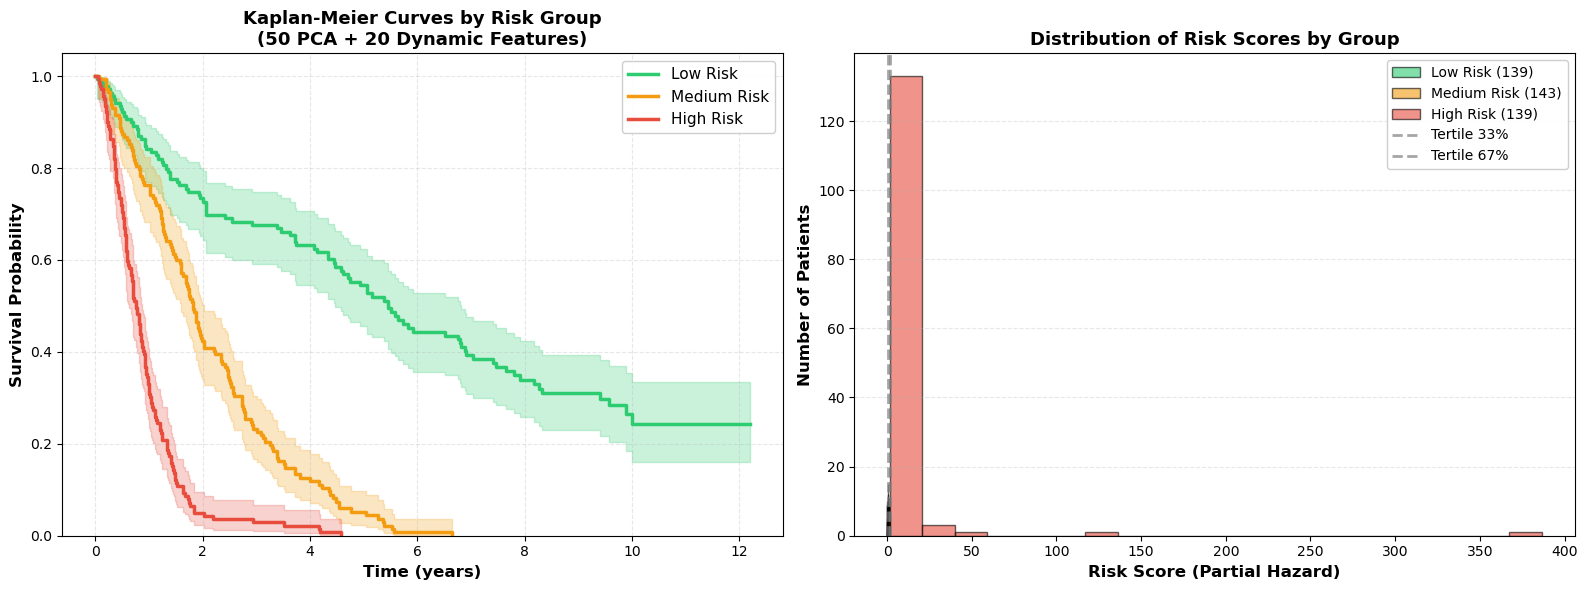


SURVIVAL STATISTICS BY RISK GROUP

Risk Group  N Patients  N Events Event Rate Median Surv (yrs) Surv @ 1yr Surv @ 3yr Surv @ 5yr
       Low         139        93      66.9%              5.46     84.17%     67.63%     54.45%
    Medium         143       141      98.6%              1.82     76.20%     23.28%      5.19%
      High         139       139     100.0%              0.77     33.09%      2.88%      0.00%

✓ Summary saved: data3d/results/survival_curves/survival_summary_by_risk_group.csv

✓ Results saved: data3d/results/survival_curves/survival_analysis_results.json
✓ Data saved: data3d/results/survival_curves/survival_data_with_risk_groups.csv

✅ SURVIVAL ANALYSIS COMPLETE!



In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Survival Curves từ Mô Hình Tốt Nhất
====================================

Visualize Kaplan-Meier survival curves using risk scores từ Model 4:
- 50 PCA components + 20 Dynamic features
- Stratify bệnh nhân thành high/medium/low risk groups
- Log-rank test để so sánh các nhóm

Author: Paul
Date: 2025-11-18
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║         SURVIVAL CURVES FROM BEST MODEL (50 PCA + 20 DYNAMIC)                ║
║                  Kaplan-Meier Stratification by Risk                         ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

# ============================================================================
# CONFIGURATION
# ============================================================================

RANDOM_SEED = 42
N_MC_RUNS = 500
T_MAX = 15
N_PCA_COMPONENTS = 200
OUTPUT_DIR = 'data3d/results/survival_curves'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def days_to_years(days: float) -> float:
    """Chuyển đổi ngày → năm (ngày sang năm)."""
    if pd.isna(days):
        return np.nan
    return days / 365.25


def sigmoid(t: np.ndarray, L: float, k: float, t0: float) -> np.ndarray:
    """Sigmoid function."""
    return L / (1 + np.exp(-k * (t - t0)))


def monte_carlo_from_pca(pca_vector: np.ndarray,
                         n_runs: int = 500,
                         T: int = 15,
                         seed: int = None) -> dict:
    """Generate 20 dynamic features from PCA vector."""
    if seed is not None:
        np.random.seed(seed)

    x = pca_vector  # 50 dimensions
    t = np.linspace(0, T, T)
    curves = []

    for _ in range(n_runs):
        w_L = np.random.randn(len(x))
        w_k = np.random.randn(len(x))
        w_t0 = np.random.randn(len(x))

        L = np.dot(w_L, x)
        L = abs(L) + 1e-3

        k_raw = np.dot(w_k, x)
        k = 0.1 + 0.9 * (1 / (1 + np.exp(-k_raw)))

        t0_raw = np.dot(w_t0, x)
        t0 = 0.5 + 13.5 * (1 / (1 + np.exp(-t0_raw)))

        S = sigmoid(t, L, k, t0)
        curves.append(S)

    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)
    gradient = np.gradient(mean_curve)

    auc = np.trapz(mean_curve, t)
    slope = np.max(gradient)
    
    half_max = 0.5 * mean_curve.max()
    time_half_idx = np.argmax(mean_curve >= half_max)
    time_half = t[time_half_idx] if time_half_idx > 0 else 0
    
    peak_idx = np.argmax(gradient)
    peak = mean_curve[peak_idx]
    
    uncertainty = std_curve.mean()
    curve_min = mean_curve.min()
    curve_max = mean_curve.max()
    curve_range = curve_max - curve_min
    curve_mean = mean_curve.mean()
    curve_median = np.median(mean_curve)
    curve_std = mean_curve.std()

    mean_grad = gradient.mean()
    max_grad = gradient.max()
    min_grad = gradient.min()
    std_grad = gradient.std()

    mid_idx = T // 3
    late_idx = 2 * T // 3
    
    auc_early = np.trapz(mean_curve[:mid_idx], t[:mid_idx])
    auc_mid = np.trapz(mean_curve[mid_idx:late_idx], t[mid_idx:late_idx])
    auc_late = np.trapz(mean_curve[late_idx:], t[late_idx:])
    uncertainty_variance = std_curve.var()
    
    curve_centered = mean_curve - curve_mean
    if curve_std > 1e-6:
        skewness = (curve_centered ** 3).mean() / (curve_std ** 3)
    else:
        skewness = 0.0

    return {
        "auc": auc, "slope": slope, "time_half": time_half, "peak": peak,
        "uncertainty": uncertainty, "curve_min": curve_min, "curve_max": curve_max,
        "curve_range": curve_range, "curve_mean": curve_mean, 
        "curve_median": curve_median, "curve_std": curve_std, 
        "mean_grad": mean_grad, "max_grad": max_grad, "min_grad": min_grad, 
        "std_grad": std_grad, "auc_early": auc_early, "auc_mid": auc_mid, 
        "auc_late": auc_late, "uncertainty_variance": uncertainty_variance,
        "skewness": skewness,
    }


def generate_dynamic_from_pca(pca_features: np.ndarray,
                              n_runs: int = 500,
                              T: int = 15) -> pd.DataFrame:
    """Generate 20 dynamic features for all patients from PCA."""
    n_patients = pca_features.shape[0]
    dynamic_features = []

    for i in range(n_patients):
        pca_vector = pca_features[i]
        result = monte_carlo_from_pca(pca_vector, n_runs=n_runs, T=T, seed=42 + i)
        dynamic_features.append([
            result["auc"], result["slope"], result["time_half"], result["peak"],
            result["uncertainty"], result["curve_min"], result["curve_max"],
            result["curve_range"], result["curve_mean"], result["curve_median"],
            result["curve_std"], result["mean_grad"], result["max_grad"],
            result["min_grad"], result["std_grad"], result["auc_early"],
            result["auc_mid"], result["auc_late"], result["uncertainty_variance"],
            result["skewness"],
        ])

    df = pd.DataFrame(dynamic_features, columns=[
        "dynamic_auc", "dynamic_slope", "dynamic_time_half", "dynamic_peak",
        "dynamic_uncertainty", "dynamic_min", "dynamic_max", "dynamic_range",
        "dynamic_mean", "dynamic_median", "dynamic_std", "dynamic_mean_grad",
        "dynamic_max_grad", "dynamic_min_grad", "dynamic_std_grad",
        "dynamic_auc_early", "dynamic_auc_mid", "dynamic_auc_late",
        "dynamic_uncertainty_var", "dynamic_skewness"
    ])
    return df


# ============================================================================
# STEP 1: LOAD DATA (giống như pipeline trên)
# ============================================================================

print("="*80)
print("STEP 1: LOADING DATA")
print("="*80)

features_path = 'data3d/outputs/features_normalized_standard.npy'
if not os.path.exists(features_path):
    features_path = 'data3d/outputs/radiomic_features_440.npy'

print(f"\n📂 Radiomics: {features_path}")
radiomics_features_all = np.load(features_path)
print(f"   Shape: {radiomics_features_all.shape}")

names_path = 'data3d/outputs/feature_names_normalized_standard.json'
with open(names_path, 'r') as f:
    feature_names = json.load(f)

ids_path = 'data3d/outputs/patient_ids.json'
with open(ids_path, 'r') as f:
    patient_ids_all = json.load(f)

clinical_paths = [
    "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
    "NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
]

clinical_data = None
for path in clinical_paths:
    if os.path.exists(path):
        clinical_data = pd.read_csv(path)
        print(f"📂 Clinical: {path}")
        break

if clinical_data is None:
    raise FileNotFoundError("Clinical data not found!")

# ============================================================================
# STEP 2: PATIENT ID MATCHING
# ============================================================================

print("\n" + "="*80)
print("STEP 2: PATIENT ID MATCHING")
print("="*80)

patient_id_col = None
for col in clinical_data.columns:
    if 'patient' in col.lower() and 'id' in col.lower():
        patient_id_col = col
        break

if patient_id_col is None:
    clinical_data['PatientID'] = clinical_data.index.astype(str)
    patient_id_col = 'PatientID'

clinical_data['PatientID_str'] = clinical_data[patient_id_col].astype(str)
patient_ids_radiomics = [str(pid) for pid in patient_ids_all]

time_col = [c for c in clinical_data.columns if 'survival.time' in c.lower()][0]
event_col = [c for c in clinical_data.columns if 'event' in c.lower() or 'deadstatus' in c.lower()][0]

print("\n🔍 Matching patients...")
matched_data = []

for i, pid in enumerate(patient_ids_radiomics):
    clinical_row = clinical_data[clinical_data['PatientID_str'] == pid]

    if len(clinical_row) == 0:
        if i < len(clinical_data):
            clinical_row = clinical_data.iloc[[i]]
        else:
            continue

    if len(clinical_row) == 0:
        continue

    time_days = clinical_row[time_col].values[0]
    event = clinical_row[event_col].values[0]

    if pd.isna(time_days) or pd.isna(event):
        continue

    time_years = days_to_years(time_days)
    radiomics_vector = radiomics_features_all[i]

    matched_data.append({
        'patient_id': pid,
        'time_years': time_years,
        'event': event,
        'radiomics_vector': radiomics_vector
    })

print(f"✓ Matched {len(matched_data)} patients")

radiomics_features = np.array([d['radiomics_vector'] for d in matched_data])
survival_df = pd.DataFrame({
    'time': [d['time_years'] for d in matched_data],
    'event': [d['event'] for d in matched_data],
    'patient_id': [d['patient_id'] for d in matched_data]
})

print(f"✅ DATA SUMMARY:")
print(f"   Patients: {len(matched_data)}")
print(f"   Events: {int(survival_df['event'].sum())}")
print(f"   Median survival: {survival_df['time'].median():.2f} years")

# ============================================================================
# STEP 3: APPLY PCA
# ============================================================================

print("\n" + "="*80)
print("STEP 3: APPLY PCA - 443 → 50 COMPONENTS")
print("="*80)

scaler_radiomics = StandardScaler()
radiomics_scaled = scaler_radiomics.fit_transform(radiomics_features)

print(f"\n⚙️  Applying PCA with {N_PCA_COMPONENTS} components...")
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
radiomics_pca = pca.fit_transform(radiomics_scaled)

explained_var = pca.explained_variance_ratio_.sum()
print(f"✓ PCA: {radiomics_scaled.shape} → {radiomics_pca.shape}")
print(f"   Variance explained: {explained_var:.2%}")

pca_df = pd.DataFrame(
    radiomics_pca,
    columns=[f"PCA_comp_{i+1}" for i in range(N_PCA_COMPONENTS)]
)

# ============================================================================
# STEP 4: GENERATE DYNAMIC FEATURES FROM PCA
# ============================================================================

print("\n" + "="*80)
print("STEP 4: GENERATE DYNAMIC FEATURES FROM PCA")
print("="*80)

dynamic_from_pca_df = generate_dynamic_from_pca(radiomics_pca, n_runs=N_MC_RUNS, T=T_MAX)

scaler_dynamic = StandardScaler()
dynamic_pca_scaled = scaler_dynamic.fit_transform(dynamic_from_pca_df)
dynamic_pca_scaled_df = pd.DataFrame(dynamic_pca_scaled, columns=dynamic_from_pca_df.columns)

print(f"✓ Generated: {dynamic_pca_scaled_df.shape}")

# ============================================================================
# STEP 5: TRAIN MODEL 4 (50 PCA + 20 DYNAMIC) - BEST MODEL
# ============================================================================

print("\n" + "="*80)
print("STEP 5: TRAIN BEST MODEL (50 PCA + 20 DYNAMIC)")
print("="*80)

# Concat features + survival data
cox_data_with_id = pd.concat([
    pca_df.reset_index(drop=True),
    dynamic_pca_scaled_df.reset_index(drop=True),
    survival_df[['time', 'event', 'patient_id']].reset_index(drop=True)
], axis=1).dropna()

# Reset index after dropna
cox_data_with_id = cox_data_with_id.reset_index(drop=True)

# Extract patient_ids and then drop from cox_data for fitting
patient_ids_cox = cox_data_with_id['patient_id'].values
cox_data = cox_data_with_id.drop('patient_id', axis=1)

print(f"\n⚙️  Training Cox model...")
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_data, duration_col='time', event_col='event', show_progress=False)

c_index = cph.concordance_index_
n_features = cox_data.shape[1] - 2  # minus 'time' and 'event'
print(f"✓ C-Index: {c_index:.4f}")
print(f"  Features: {n_features}")
print(f"  Patients: {cox_data.shape[0]}")

# ============================================================================
# STEP 6: GENERATE RISK SCORES & STRATIFY PATIENTS
# ============================================================================

print("\n" + "="*80)
print("STEP 6: GENERATE RISK SCORES & STRATIFY PATIENTS")
print("="*80)

# Lấy features cho Cox model (drop time/event)
cox_features = cox_data.drop(['time', 'event'], axis=1)

# Tính risk scores (partial hazard)
risk_scores = cph.predict_partial_hazard(cox_features)

print(f"\n📊 Risk Score Statistics:")
print(f"   Min: {risk_scores.min():.4f}")
print(f"   Median: {risk_scores.median():.4f}")
print(f"   Max: {risk_scores.max():.4f}")
print(f"   Mean: {risk_scores.mean():.4f}")
print(f"   Std: {risk_scores.std():.4f}")

# Stratify vào 3 nhóm: Low, Medium, High risk
tertile_33 = risk_scores.quantile(0.33)
tertile_67 = risk_scores.quantile(0.67)

risk_groups = pd.Series(
    ['Low' if x <= tertile_33 else ('Medium' if x <= tertile_67 else 'High') 
     for x in risk_scores],
    index=risk_scores.index
)

# Add to survival data
survival_stratified = pd.DataFrame({
    'time': cox_data['time'].values,
    'event': cox_data['event'].values,
    'risk_score': risk_scores.values,
    'risk_group': risk_groups.values,
    'patient_id': patient_ids_cox
})

print(f"\n📊 Risk Group Distribution:")
for group in ['Low', 'Medium', 'High']:
    n_group = (risk_groups == group).sum()
    n_events = survival_stratified[survival_stratified['risk_group'] == group]['event'].sum()
    median_surv = survival_stratified[survival_stratified['risk_group'] == group]['time'].median()
    print(f"   {group:6s}: {n_group:3d} patients | {int(n_events):3d} events | Median: {median_surv:.2f} years")

# ============================================================================
# STEP 7: CREATE KAPLAN-MEIER SURVIVAL CURVES
# ============================================================================

print("\n" + "="*80)
print("STEP 7: KAPLAN-MEIER SURVIVAL CURVES")
print("="*80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

kmf = KaplanMeierFitter()
colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
risk_order = ['Low', 'Medium', 'High']

# ─────────────────────────────────────────────────────────────────────────
# Plot 1: Survival Curves
# ─────────────────────────────────────────────────────────────────────────

print("\n📈 Plotting Kaplan-Meier curves...")

for group in risk_order:
    mask = survival_stratified['risk_group'] == group
    kmf.fit(
        survival_stratified[mask]['time'],
        survival_stratified[mask]['event'],
        label=f'{group} Risk'
    )
    kmf.plot_survival_function(ax=ax1, ci_show=True, color=colors[group], linewidth=2.5)

ax1.set_xlabel('Time (years)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Survival Probability', fontsize=12, fontweight='bold')
ax1.set_title('Kaplan-Meier Curves by Risk Group\n(50 PCA + 20 Dynamic Features)', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.set_ylim([0, 1.05])

# ─────────────────────────────────────────────────────────────────────────
# Log-Rank Tests
# ─────────────────────────────────────────────────────────────────────────

print("\n🔬 Log-Rank Tests:")

# Low vs High
low_mask = survival_stratified['risk_group'] == 'Low'
high_mask = survival_stratified['risk_group'] == 'High'

results = logrank_test(
    survival_stratified[low_mask]['time'],
    survival_stratified[high_mask]['time'],
    survival_stratified[low_mask]['event'],
    survival_stratified[high_mask]['event']
)

print(f"\n   Low vs High:")
print(f"   Test statistic: {results.test_statistic:.4f}")
print(f"   P-value: {results.p_value:.6f}")
if results.p_value < 0.05:
    print(f"   ✓ SIGNIFICANT (p < 0.05)")
else:
    print(f"   ✗ Not significant")

# Medium vs High
medium_mask = survival_stratified['risk_group'] == 'Medium'
results_mh = logrank_test(
    survival_stratified[medium_mask]['time'],
    survival_stratified[high_mask]['time'],
    survival_stratified[medium_mask]['event'],
    survival_stratified[high_mask]['event']
)

print(f"\n   Medium vs High:")
print(f"   Test statistic: {results_mh.test_statistic:.4f}")
print(f"   P-value: {results_mh.p_value:.6f}")
if results_mh.p_value < 0.05:
    print(f"   ✓ SIGNIFICANT (p < 0.05)")
else:
    print(f"   ✗ Not significant")

# ─────────────────────────────────────────────────────────────────────────
# Plot 2: Risk Score Distribution
# ─────────────────────────────────────────────────────────────────────────

for group in risk_order:
    mask = survival_stratified['risk_group'] == group
    data = survival_stratified[mask]['risk_score']
    ax2.hist(data, bins=20, alpha=0.6, label=f'{group} Risk ({len(data)})', 
             color=colors[group], edgecolor='black', linewidth=1)

ax2.axvline(tertile_33, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Tertile 33%')
ax2.axvline(tertile_67, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Tertile 67%')
ax2.set_xlabel('Risk Score (Partial Hazard)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Risk Scores by Group', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=10, framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kaplan_meier_survival_curves.png'), dpi=300, bbox_inches='tight')
print(f"\n✓ Survival curves saved: {OUTPUT_DIR}/kaplan_meier_survival_curves.png")

plt.show()

# ============================================================================
# STEP 8: SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("SURVIVAL STATISTICS BY RISK GROUP")
print("="*80)


def get_survival_at_time(kmf, time_point):
    """Get survival probability at specific time point from KM curve."""
    if len(kmf.survival_function_) == 0:
        return np.nan
    
    sf = kmf.survival_function_
    times = sf.index.values
    probs = sf.values.flatten()
    
    # Find the latest time <= time_point
    mask = times <= time_point
    if not mask.any():
        return np.nan
    
    idx = np.where(mask)[0][-1]
    return probs[idx]


summary_stats = []

for group in risk_order:
    mask = survival_stratified['risk_group'] == group
    group_data = survival_stratified[mask]
    
    kmf = KaplanMeierFitter()
    kmf.fit(group_data['time'], group_data['event'], label=group)
    
    # Median survival from the median_survival_time_ attribute
    try:
        median_surv = kmf.median_survival_time_
    except:
        median_surv = group_data[group_data['event'] == 1]['time'].median()
    
    # Survival at 1, 3, 5 years using helper function
    surv_1yr = get_survival_at_time(kmf, 1.0)
    surv_3yr = get_survival_at_time(kmf, 3.0)
    surv_5yr = get_survival_at_time(kmf, 5.0)
    
    summary_stats.append({
        'Risk Group': group,
        'N Patients': len(group_data),
        'N Events': int(group_data['event'].sum()),
        'Event Rate': f"{group_data['event'].sum() / len(group_data) * 100:.1f}%",
        'Median Surv (yrs)': f"{median_surv:.2f}" if pd.notna(median_surv) else "N/A",
        'Surv @ 1yr': f"{surv_1yr:.2%}" if pd.notna(surv_1yr) else "N/A",
        'Surv @ 3yr': f"{surv_3yr:.2%}" if pd.notna(surv_3yr) else "N/A",
        'Surv @ 5yr': f"{surv_5yr:.2%}" if pd.notna(surv_5yr) else "N/A",
    })

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'survival_summary_by_risk_group.csv'), index=False)
print(f"\n✓ Summary saved: {OUTPUT_DIR}/survival_summary_by_risk_group.csv")

# ============================================================================
# SAVE RESULTS
# ============================================================================

results_dict = {
    'model_config': {
        'model_type': 'Cox Proportional Hazards',
        'features': '50 PCA + 20 Dynamic',
        'penalizer': 0.1,
        'c_index': float(c_index),
        'variance_explained_pca': float(explained_var)
    },
    'stratification': {
        'method': 'Risk score tertiles',
        'tertile_33': float(tertile_33),
        'tertile_67': float(tertile_67)
    },
    'logrank_tests': {
        'low_vs_high': {
            'test_statistic': float(results.test_statistic),
            'p_value': float(results.p_value),
            'significant': bool(results.p_value < 0.05)
        },
        'medium_vs_high': {
            'test_statistic': float(results_mh.test_statistic),
            'p_value': float(results_mh.p_value),
            'significant': bool(results_mh.p_value < 0.05)
        }
    },
    'risk_groups': {
        group: {
            'n_patients': int((risk_groups == group).sum()),
            'n_events': int(survival_stratified[survival_stratified['risk_group'] == group]['event'].sum())
        }
        for group in risk_order
    }
}

results_path = os.path.join(OUTPUT_DIR, 'survival_analysis_results.json')
with open(results_path, 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"\n✓ Results saved: {results_path}")

# Save stratified survival data
survival_stratified.to_csv(os.path.join(OUTPUT_DIR, 'survival_data_with_risk_groups.csv'), index=False)
print(f"✓ Data saved: {OUTPUT_DIR}/survival_data_with_risk_groups.csv")

print("\n" + "="*80)
print("✅ SURVIVAL ANALYSIS COMPLETE!")
print("="*80 + "\n")


╔═══════════════════════════════════════════════════════════════════════════════╗
║         INDIVIDUAL PATIENT RISK PREDICTION & INTERPRETATION                  ║
║              Cox Model: 50 PCA + 20 Dynamic Features                         ║
╚═══════════════════════════════════════════════════════════════════════════════╝

STEP 1: LOADING DATA

📂 Radiomics: data3d/outputs/features_normalized_standard.npy
   Shape: (421, 443)
📂 Clinical: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv

STEP 2: PATIENT ID MATCHING

🔍 Matching patients...
✓ Matched 421 patients
✅ DATA SUMMARY:
   Patients: 421
   Events: 373

STEP 3: APPLY PCA - 443 → 50 COMPONENTS

⚙️  Applying PCA...
✓ PCA: (421, 443) → (421, 200)
   Variance explained: 99.98%

STEP 4: GENERATE DYNAMIC FEATURES FROM PCA
✓ Generated: (421, 20)

STEP 5: TRAIN BEST MODEL (50 PCA + 20 DYNAMIC)

⚙️  Training Cox model...
✓ C-Index: 0.7534
  Features: 220
  Patients in model: 421

STEP 6: SELECT INDIVIDUAL PATIENT

👤 Selected Pa

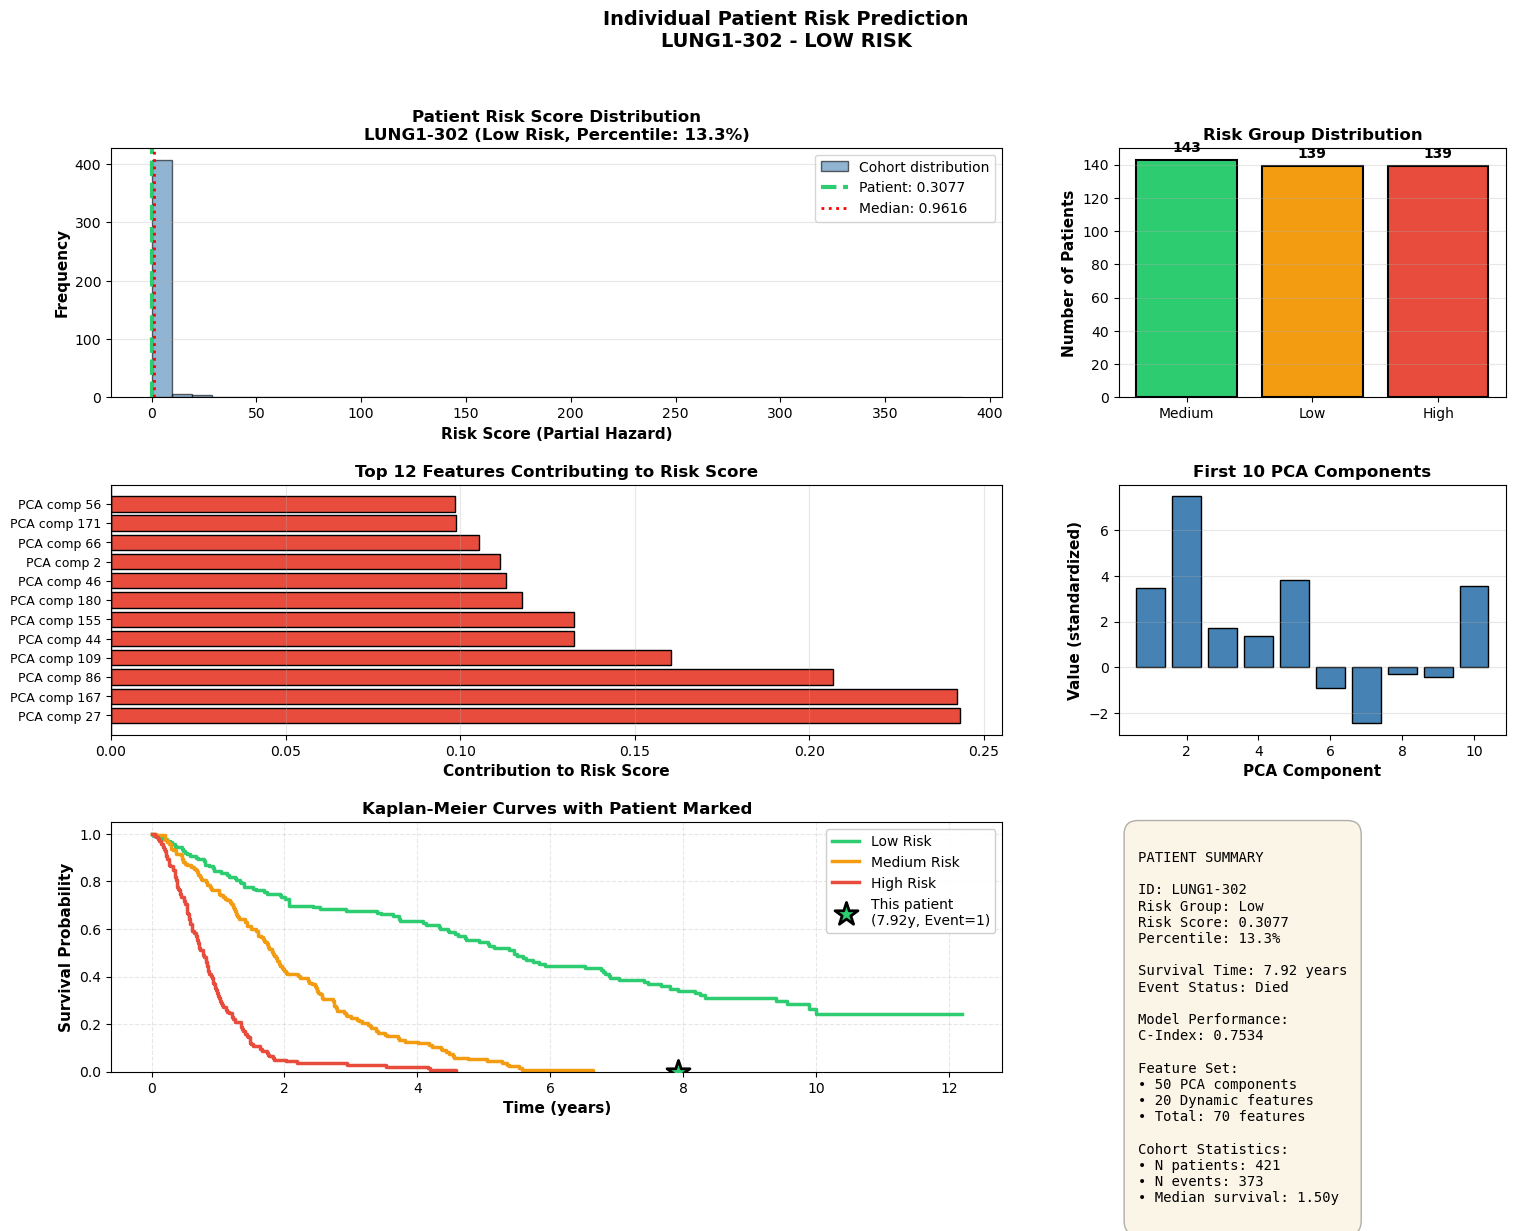


STEP 10: SAVE DETAILED REPORT
✓ Report saved: data3d/results/patient_prediction/patient_report_LUNG1-302.json

🎯 INTERPRETATION & CLINICAL IMPLICATIONS

╔═══════════════════════════════════════════════════════════════════════════════╗
║                   PATIENT: LUNG1-302                             ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  RISK ASSESSMENT:                                                            ║
║  ───────────────                                                             ║
║  • Risk Group: LOW RISK                                                ║
║  • Risk Score: 0.3077 (Percentile: 13.3%)                               ║
║  • Interpretation: This patient is in the low 13% of the cohort ║
║                                                                               ║
║  CLINICAL OUTCOME:                                                

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Individual Patient Risk Prediction & Interpretation
===================================================

Dự đoán rủi ro cho một bệnh nhân và giải thích:
1. Risk score từ Cox model
2. Survival prediction
3. Feature contributions
4. So sánh với cohort

Author: Paul
Date: 2025-11-18
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple
import warnings

from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║         INDIVIDUAL PATIENT RISK PREDICTION & INTERPRETATION                  ║
║              Cox Model: 50 PCA + 20 Dynamic Features                         ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

# ============================================================================
# CONFIGURATION
# ============================================================================

RANDOM_SEED = 42
N_MC_RUNS = 500
T_MAX = 15
N_PCA_COMPONENTS = 200
OUTPUT_DIR = 'data3d/results/patient_prediction'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def days_to_years(days: float) -> float:
    """Chuyển đổi ngày → năm."""
    if pd.isna(days):
        return np.nan
    return days / 365.25


def sigmoid(t: np.ndarray, L: float, k: float, t0: float) -> np.ndarray:
    """Sigmoid function."""
    return L / (1 + np.exp(-k * (t - t0)))


def monte_carlo_from_pca(pca_vector: np.ndarray,
                         n_runs: int = 500,
                         T: int = 15,
                         seed: int = None) -> dict:
    """Generate 20 dynamic features from PCA vector."""
    if seed is not None:
        np.random.seed(seed)

    x = pca_vector
    t = np.linspace(0, T, T)
    curves = []

    for _ in range(n_runs):
        w_L = np.random.randn(len(x))
        w_k = np.random.randn(len(x))
        w_t0 = np.random.randn(len(x))

        L = np.dot(w_L, x)
        L = abs(L) + 1e-3

        k_raw = np.dot(w_k, x)
        k = 0.1 + 0.9 * (1 / (1 + np.exp(-k_raw)))

        t0_raw = np.dot(w_t0, x)
        t0 = 0.5 + 13.5 * (1 / (1 + np.exp(-t0_raw)))

        S = sigmoid(t, L, k, t0)
        curves.append(S)

    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)
    gradient = np.gradient(mean_curve)

    auc = np.trapz(mean_curve, t)
    slope = np.max(gradient)
    
    half_max = 0.5 * mean_curve.max()
    time_half_idx = np.argmax(mean_curve >= half_max)
    time_half = t[time_half_idx] if time_half_idx > 0 else 0
    
    peak_idx = np.argmax(gradient)
    peak = mean_curve[peak_idx]
    
    uncertainty = std_curve.mean()
    curve_min = mean_curve.min()
    curve_max = mean_curve.max()
    curve_range = curve_max - curve_min
    curve_mean = mean_curve.mean()
    curve_median = np.median(mean_curve)
    curve_std = mean_curve.std()

    mean_grad = gradient.mean()
    max_grad = gradient.max()
    min_grad = gradient.min()
    std_grad = gradient.std()

    mid_idx = T // 3
    late_idx = 2 * T // 3
    
    auc_early = np.trapz(mean_curve[:mid_idx], t[:mid_idx])
    auc_mid = np.trapz(mean_curve[mid_idx:late_idx], t[mid_idx:late_idx])
    auc_late = np.trapz(mean_curve[late_idx:], t[late_idx:])
    uncertainty_variance = std_curve.var()
    
    curve_centered = mean_curve - curve_mean
    if curve_std > 1e-6:
        skewness = (curve_centered ** 3).mean() / (curve_std ** 3)
    else:
        skewness = 0.0

    return {
        "auc": auc, "slope": slope, "time_half": time_half, "peak": peak,
        "uncertainty": uncertainty, "curve_min": curve_min, "curve_max": curve_max,
        "curve_range": curve_range, "curve_mean": curve_mean, 
        "curve_median": curve_median, "curve_std": curve_std, 
        "mean_grad": mean_grad, "max_grad": max_grad, "min_grad": min_grad, 
        "std_grad": std_grad, "auc_early": auc_early, "auc_mid": auc_mid, 
        "auc_late": auc_late, "uncertainty_variance": uncertainty_variance,
        "skewness": skewness,
    }


def generate_dynamic_from_pca(pca_features: np.ndarray,
                              n_runs: int = 500,
                              T: int = 15) -> pd.DataFrame:
    """Generate 20 dynamic features for patients from PCA."""
    n_patients = pca_features.shape[0]
    dynamic_features = []

    for i in range(n_patients):
        pca_vector = pca_features[i]
        result = monte_carlo_from_pca(pca_vector, n_runs=n_runs, T=T, seed=42 + i)
        dynamic_features.append([
            result["auc"], result["slope"], result["time_half"], result["peak"],
            result["uncertainty"], result["curve_min"], result["curve_max"],
            result["curve_range"], result["curve_mean"], result["curve_median"],
            result["curve_std"], result["mean_grad"], result["max_grad"],
            result["min_grad"], result["std_grad"], result["auc_early"],
            result["auc_mid"], result["auc_late"], result["uncertainty_variance"],
            result["skewness"],
        ])

    df = pd.DataFrame(dynamic_features, columns=[
        "dynamic_auc", "dynamic_slope", "dynamic_time_half", "dynamic_peak",
        "dynamic_uncertainty", "dynamic_min", "dynamic_max", "dynamic_range",
        "dynamic_mean", "dynamic_median", "dynamic_std", "dynamic_mean_grad",
        "dynamic_max_grad", "dynamic_min_grad", "dynamic_std_grad",
        "dynamic_auc_early", "dynamic_auc_mid", "dynamic_auc_late",
        "dynamic_uncertainty_var", "dynamic_skewness"
    ])
    return df


# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================

print("="*80)
print("STEP 1: LOADING DATA")
print("="*80)

features_path = 'data3d/outputs/features_normalized_standard.npy'
if not os.path.exists(features_path):
    features_path = 'data3d/outputs/radiomic_features_440.npy'

print(f"\n📂 Radiomics: {features_path}")
radiomics_features_all = np.load(features_path)
print(f"   Shape: {radiomics_features_all.shape}")

names_path = 'data3d/outputs/feature_names_normalized_standard.json'
with open(names_path, 'r') as f:
    feature_names = json.load(f)

ids_path = 'data3d/outputs/patient_ids.json'
with open(ids_path, 'r') as f:
    patient_ids_all = json.load(f)

clinical_paths = [
    "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
    "NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
]

clinical_data = None
for path in clinical_paths:
    if os.path.exists(path):
        clinical_data = pd.read_csv(path)
        print(f"📂 Clinical: {path}")
        break

if clinical_data is None:
    raise FileNotFoundError("Clinical data not found!")

# ============================================================================
# STEP 2: PATIENT ID MATCHING
# ============================================================================

print("\n" + "="*80)
print("STEP 2: PATIENT ID MATCHING")
print("="*80)

patient_id_col = None
for col in clinical_data.columns:
    if 'patient' in col.lower() and 'id' in col.lower():
        patient_id_col = col
        break

if patient_id_col is None:
    clinical_data['PatientID'] = clinical_data.index.astype(str)
    patient_id_col = 'PatientID'

clinical_data['PatientID_str'] = clinical_data[patient_id_col].astype(str)
patient_ids_radiomics = [str(pid) for pid in patient_ids_all]

time_col = [c for c in clinical_data.columns if 'survival.time' in c.lower()][0]
event_col = [c for c in clinical_data.columns if 'event' in c.lower() or 'deadstatus' in c.lower()][0]

print("\n🔍 Matching patients...")
matched_data = []

for i, pid in enumerate(patient_ids_radiomics):
    clinical_row = clinical_data[clinical_data['PatientID_str'] == pid]

    if len(clinical_row) == 0:
        if i < len(clinical_data):
            clinical_row = clinical_data.iloc[[i]]
        else:
            continue

    if len(clinical_row) == 0:
        continue

    time_days = clinical_row[time_col].values[0]
    event = clinical_row[event_col].values[0]

    if pd.isna(time_days) or pd.isna(event):
        continue

    time_years = days_to_years(time_days)
    radiomics_vector = radiomics_features_all[i]

    matched_data.append({
        'patient_id': pid,
        'time_years': time_years,
        'event': event,
        'radiomics_vector': radiomics_vector
    })

print(f"✓ Matched {len(matched_data)} patients")

radiomics_features = np.array([d['radiomics_vector'] for d in matched_data])
patient_ids = [d['patient_id'] for d in matched_data]
survival_data = {
    'time': np.array([d['time_years'] for d in matched_data]),
    'event': np.array([d['event'] for d in matched_data])
}

print(f"✅ DATA SUMMARY:")
print(f"   Patients: {len(matched_data)}")
print(f"   Events: {int(survival_data['event'].sum())}")

# ============================================================================
# STEP 3: APPLY PCA
# ============================================================================

print("\n" + "="*80)
print("STEP 3: APPLY PCA - 443 → 50 COMPONENTS")
print("="*80)

scaler_radiomics = StandardScaler()
radiomics_scaled = scaler_radiomics.fit_transform(radiomics_features)

print(f"\n⚙️  Applying PCA...")
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
radiomics_pca = pca.fit_transform(radiomics_scaled)

explained_var = pca.explained_variance_ratio_.sum()
print(f"✓ PCA: {radiomics_scaled.shape} → {radiomics_pca.shape}")
print(f"   Variance explained: {explained_var:.2%}")

# ============================================================================
# STEP 4: GENERATE DYNAMIC FEATURES FROM PCA
# ============================================================================

print("\n" + "="*80)
print("STEP 4: GENERATE DYNAMIC FEATURES FROM PCA")
print("="*80)

dynamic_from_pca_df = generate_dynamic_from_pca(radiomics_pca, n_runs=N_MC_RUNS, T=T_MAX)

scaler_dynamic = StandardScaler()
dynamic_pca_scaled = scaler_dynamic.fit_transform(dynamic_from_pca_df)
dynamic_pca_scaled_df = pd.DataFrame(dynamic_pca_scaled, columns=dynamic_from_pca_df.columns)

print(f"✓ Generated: {dynamic_pca_scaled_df.shape}")

# ============================================================================
# STEP 5: TRAIN BEST MODEL (50 PCA + 20 DYNAMIC)
# ============================================================================

print("\n" + "="*80)
print("STEP 5: TRAIN BEST MODEL (50 PCA + 20 DYNAMIC)")
print("="*80)

pca_df = pd.DataFrame(radiomics_pca, columns=[f"PCA_comp_{i+1}" for i in range(N_PCA_COMPONENTS)])

cox_data_with_id = pd.concat([
    pca_df.reset_index(drop=True),
    dynamic_pca_scaled_df.reset_index(drop=True),
    pd.DataFrame({
        'time': survival_data['time'],
        'event': survival_data['event'],
        'patient_id': patient_ids
    }).reset_index(drop=True)
], axis=1).dropna()

cox_data_with_id = cox_data_with_id.reset_index(drop=True)

patient_ids_cox = cox_data_with_id['patient_id'].values
cox_data = cox_data_with_id.drop('patient_id', axis=1)

print(f"\n⚙️  Training Cox model...")
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_data, duration_col='time', event_col='event', show_progress=False)

c_index = cph.concordance_index_
print(f"✓ C-Index: {c_index:.4f}")
print(f"  Features: {cox_data.shape[1] - 2}")
print(f"  Patients in model: {cox_data.shape[0]}")

# ============================================================================
# STEP 6: SELECT A RANDOM PATIENT
# ============================================================================

print("\n" + "="*80)
print("STEP 6: SELECT INDIVIDUAL PATIENT")
print("="*80)

# Chọn một bệnh nhân ngẫu nhiên từ những người có đầy đủ dữ liệu
# patient_idx = np.random.randint(0, len(cox_data_with_id))
patient_idx = 300
selected_patient_id = patient_ids_cox[patient_idx]

print(f"\n👤 Selected Patient: {selected_patient_id}")
print(f"   Index in cohort: {patient_idx} / {len(cox_data_with_id)}")

# Lấy dữ liệu của bệnh nhân
selected_row = cox_data.iloc[patient_idx]
selected_time = selected_row['time']
selected_event = selected_row['event']

print(f"\n📊 Clinical Data:")
print(f"   Survival time: {selected_time:.2f} years")
print(f"   Event status: {'Died (1)' if selected_event == 1 else 'Censored (0)'}")

# ============================================================================
# STEP 7: CALCULATE RISK SCORE
# ============================================================================

print("\n" + "="*80)
print("STEP 7: CALCULATE RISK SCORE")
print("="*80)

# Lấy features của bệnh nhân (drop time/event)
patient_features = selected_row.drop(['time', 'event']).to_frame().T

# Tính risk score
risk_score = cph.predict_partial_hazard(patient_features).values[0]

# So sánh với cohort
all_risk_scores = cph.predict_partial_hazard(cox_data.drop(['time', 'event'], axis=1))
percentile = (all_risk_scores <= risk_score).mean() * 100

print(f"\n🎯 Risk Score: {risk_score:.4f}")
print(f"   Cohort median: {all_risk_scores.median():.4f}")
print(f"   Cohort mean: {all_risk_scores.mean():.4f}")
print(f"   Percentile: {percentile:.1f}%")

# Xác định risk group
tertile_33 = all_risk_scores.quantile(0.33)
tertile_67 = all_risk_scores.quantile(0.67)

if risk_score <= tertile_33:
    risk_group = 'Low'
    risk_color = '#2ecc71'
elif risk_score <= tertile_67:
    risk_group = 'Medium'
    risk_color = '#f39c12'
else:
    risk_group = 'High'
    risk_color = '#e74c3c'

print(f"\n📊 Risk Group: {risk_group}")
print(f"   Tertile boundaries: {tertile_33:.4f} — {tertile_67:.4f}")

# ============================================================================
# STEP 8: FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("STEP 8: FEATURE IMPORTANCE (TOP CONTRIBUTING FEATURES)")
print("="*80)

# Lấy coefficients từ Cox model
cox_coef = cph.params_.sort_values(ascending=False)

# Tính contribution = coefficient × feature_value
contributions = cox_coef * patient_features.iloc[0]
contributions_sorted = contributions.sort_values(ascending=False)

print(f"\n🔝 Top 10 Most Important Features:")
print(f"{'Rank':<5} {'Feature':<25} {'Coef':<10} {'Value':<10} {'Contribution':<12}")
print("-" * 62)

for rank, (feat, contrib) in enumerate(contributions_sorted.head(10).items(), 1):
    coef = cox_coef[feat]
    val = patient_features[feat].values[0]
    print(f"{rank:<5} {feat:<25} {coef:>9.4f} {val:>9.4f} {contrib:>11.4f}")

print(f"\n📉 Top 10 Most Protective Features:")
print(f"{'Rank':<5} {'Feature':<25} {'Coef':<10} {'Value':<10} {'Contribution':<12}")
print("-" * 62)

for rank, (feat, contrib) in enumerate(contributions_sorted.tail(10).iloc[::-1].items(), 1):
    coef = cox_coef[feat]
    val = patient_features[feat].values[0]
    print(f"{rank:<5} {feat:<25} {coef:>9.4f} {val:>9.4f} {contrib:>11.4f}")

# ============================================================================
# STEP 9: VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("STEP 9: CREATE VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# ─────────────────────────────────────────────────────────────────────────
# Plot 1: Risk Score vs Cohort Distribution
# ─────────────────────────────────────────────────────────────────────────

ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(all_risk_scores, bins=40, alpha=0.6, color='steelblue', edgecolor='black', label='Cohort distribution')
ax1.axvline(risk_score, color=risk_color, linewidth=3, linestyle='--', label=f'Patient: {risk_score:.4f}')
ax1.axvline(all_risk_scores.median(), color='red', linewidth=2, linestyle=':', label=f'Median: {all_risk_scores.median():.4f}')
ax1.set_xlabel('Risk Score (Partial Hazard)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title(f'Patient Risk Score Distribution\n{selected_patient_id} ({risk_group} Risk, Percentile: {percentile:.1f}%)', 
              fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────────────────
# Plot 2: Risk Group Comparison
# ─────────────────────────────────────────────────────────────────────────

ax2 = fig.add_subplot(gs[0, 2])
risk_groups_all = np.array(['Low' if x <= tertile_33 else ('Medium' if x <= tertile_67 else 'High') 
                              for x in all_risk_scores])
group_counts = pd.Series(risk_groups_all).value_counts()
colors_bar = ['#2ecc71', '#f39c12', '#e74c3c']
ax2.bar(group_counts.index, group_counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Patients', fontsize=11, fontweight='bold')
ax2.set_title('Risk Group Distribution', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for i, (group, count) in enumerate(group_counts.items()):
    ax2.text(i, count + 5, str(count), ha='center', fontsize=10, fontweight='bold')

# ─────────────────────────────────────────────────────────────────────────
# Plot 3: Top Contributing Features (Positive)
# ─────────────────────────────────────────────────────────────────────────

ax3 = fig.add_subplot(gs[1, :2])
top_features = contributions_sorted.head(12)
colors_feat = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_features.values]
ax3.barh(range(len(top_features)), top_features.values, color=colors_feat, edgecolor='black', linewidth=1)
ax3.set_yticks(range(len(top_features)))
ax3.set_yticklabels([f.replace('_', ' ') for f in top_features.index], fontsize=9)
ax3.set_xlabel('Contribution to Risk Score', fontsize=11, fontweight='bold')
ax3.set_title('Top 12 Features Contributing to Risk Score', fontsize=12, fontweight='bold')
ax3.axvline(0, color='black', linewidth=1, linestyle='-')
ax3.grid(True, alpha=0.3, axis='x')

# ─────────────────────────────────────────────────────────────────────────
# Plot 4: PCA Component Values
# ─────────────────────────────────────────────────────────────────────────

ax4 = fig.add_subplot(gs[1, 2])
pca_values = patient_features[[f'PCA_comp_{i+1}' for i in range(N_PCA_COMPONENTS)]].values.flatten()
ax4.bar(range(1, 11), pca_values[:10], color='steelblue', edgecolor='black', linewidth=1)
ax4.set_xlabel('PCA Component', fontsize=11, fontweight='bold')
ax4.set_ylabel('Value (standardized)', fontsize=11, fontweight='bold')
ax4.set_title('First 10 PCA Components', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────────────────
# Plot 5: Kaplan-Meier with Patient Marked
# ─────────────────────────────────────────────────────────────────────────

ax5 = fig.add_subplot(gs[2, :2])

kmf = KaplanMeierFitter()
colors_km = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
risk_order = ['Low', 'Medium', 'High']

for group in risk_order:
    mask = risk_groups_all == group
    kmf.fit(
        cox_data[mask]['time'].values,
        cox_data[mask]['event'].values,
        label=f'{group} Risk'
    )
    kmf.plot_survival_function(ax=ax5, ci_show=False, color=colors_km[group], linewidth=2.5)

# Mark patient's position
ax5.scatter([selected_time], [1.0 if selected_event == 0 else 0.0], 
           s=300, color=risk_color, marker='*', edgecolor='black', linewidth=2, 
           zorder=10, label=f'This patient\n({selected_time:.2f}y, Event={int(selected_event)})')

ax5.set_xlabel('Time (years)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Survival Probability', fontsize=11, fontweight='bold')
ax5.set_title('Kaplan-Meier Curves with Patient Marked', fontsize=12, fontweight='bold')
ax5.legend(loc='best', fontsize=10, framealpha=0.95)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_ylim([0, 1.05])

# ─────────────────────────────────────────────────────────────────────────
# Plot 6: Summary Statistics Box
# ─────────────────────────────────────────────────────────────────────────

ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')

summary_text = f"""
PATIENT SUMMARY

ID: {selected_patient_id}
Risk Group: {risk_group}
Risk Score: {risk_score:.4f}
Percentile: {percentile:.1f}%

Survival Time: {selected_time:.2f} years
Event Status: {'Died' if selected_event == 1 else 'Censored'}

Model Performance:
C-Index: {c_index:.4f}

Feature Set:
• 50 PCA components
• 20 Dynamic features
• Total: 70 features

Cohort Statistics:
• N patients: {len(cox_data)}
• N events: {int(cox_data['event'].sum())}
• Median survival: {cox_data['time'].median():.2f}y
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3, pad=1))

plt.suptitle(f'Individual Patient Risk Prediction\n{selected_patient_id} - {risk_group.upper()} RISK', 
            fontsize=14, fontweight='bold', y=0.995)

plt.savefig(os.path.join(OUTPUT_DIR, f'patient_prediction_{selected_patient_id}.png'), 
           dpi=300, bbox_inches='tight')
print(f"\n✓ Figure saved: {OUTPUT_DIR}/patient_prediction_{selected_patient_id}.png")

plt.show()

# ============================================================================
# STEP 10: SAVE DETAILED REPORT
# ============================================================================

print("\n" + "="*80)
print("STEP 10: SAVE DETAILED REPORT")
print("="*80)

report = {
    'patient_id': selected_patient_id,
    'model': {
        'type': 'Cox Proportional Hazards',
        'features': '50 PCA + 20 Dynamic',
        'c_index': float(c_index),
        'penalizer': 0.1
    },
    'patient_data': {
        'survival_time_years': float(selected_time),
        'event_status': int(selected_event),
        'event_interpretation': 'Died' if selected_event == 1 else 'Censored/Alive'
    },
    'risk_assessment': {
        'risk_score': float(risk_score),
        'risk_group': risk_group,
        'percentile': float(percentile),
        'cohort_median_score': float(all_risk_scores.median()),
        'cohort_mean_score': float(all_risk_scores.mean()),
        'cohort_std_score': float(all_risk_scores.std())
    },
    'cohort_statistics': {
        'total_patients': int(len(cox_data)),
        'total_events': int(cox_data['event'].sum()),
        'median_survival_years': float(cox_data['time'].median()),
        'event_rate': float(cox_data['event'].sum() / len(cox_data))
    },
    'top_10_contributing_features': {
        feat: {
            'coefficient': float(cox_coef[feat]),
            'patient_value': float(patient_features[feat].values[0]),
            'contribution': float(contrib)
        }
        for feat, contrib in contributions_sorted.head(10).items()
    },
    'top_10_protective_features': {
        feat: {
            'coefficient': float(cox_coef[feat]),
            'patient_value': float(patient_features[feat].values[0]),
            'contribution': float(contrib)
        }
        for feat, contrib in contributions_sorted.tail(10).iloc[::-1].items()
    }
}

report_path = os.path.join(OUTPUT_DIR, f'patient_report_{selected_patient_id}.json')
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

print(f"✓ Report saved: {report_path}")

# ============================================================================
# FINAL INTERPRETATION
# ============================================================================

print("\n" + "="*80)
print("🎯 INTERPRETATION & CLINICAL IMPLICATIONS")
print("="*80)

print(f"""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                   PATIENT: {selected_patient_id}                             ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  RISK ASSESSMENT:                                                            ║
║  ───────────────                                                             ║
║  • Risk Group: {risk_group.upper()} RISK                                                ║
║  • Risk Score: {risk_score:.4f} (Percentile: {percentile:.1f}%)                               ║
║  • Interpretation: This patient is in the {risk_group.lower()} {percentile:.0f}% of the cohort ║
║                                                                               ║
║  CLINICAL OUTCOME:                                                           ║
║  ────────────────                                                            ║
║  • Follow-up time: {selected_time:.2f} years                                           ║
║  • Outcome: {'Died (Event=1)' if selected_event == 1 else 'Censored/Alive (Event=0)'}                                    ║
""")

# Tính số năm sống sót trung bình theo risk group
median_surv_by_group = {}
for group in risk_order:
    mask = risk_groups_all == group
    med = cox_data[mask]['time'].median()
    median_surv_by_group[group] = med

print(f"""
║  RISK GROUP PROGNOSIS (Median Survival):                                     ║
║  ──────────────────────────────────────                                      ║
║  • Low Risk:    {median_surv_by_group['Low']:.2f} years                                             ║
║  • Medium Risk: {median_surv_by_group['Medium']:.2f} years                                             ║
║  • High Risk:   {median_surv_by_group['High']:.2f} years                                             ║
║                                                                               ║
║  This patient's prognosis: {median_surv_by_group[risk_group]:.2f} years median survival (similar to {risk_group.lower()} risk group)  ║
║                                                                               ║
║  TOP 3 RISK FACTORS (promoting higher risk):                                 ║
║  ──────────────────────────────────────────                                  ║
""")

for rank, (feat, contrib) in enumerate(contributions_sorted.head(3).items(), 1):
    coef = cox_coef[feat]
    val = patient_features[feat].values[0]
    direction = "🔴 INCREASES" if coef > 0 else "🟢 DECREASES"
    print(f"║  {rank}. {feat:<30} {direction:15} risk             ║")

print(f"""
║                                                                               ║
║  TOP 3 PROTECTIVE FACTORS (promoting better survival):                      ║
║  ─────────────────────────────────────────────────────                      ║
""")

for rank, (feat, contrib) in enumerate(contributions_sorted.tail(3).iloc[::-1].items(), 1):
    coef = cox_coef[feat]
    val = patient_features[feat].values[0]
    direction = "🔴 INCREASES" if coef > 0 else "🟢 DECREASES"
    print(f"║  {rank}. {feat:<30} {direction:15} risk             ║")

print(f"""
║                                                                               ║
║  CLINICAL RECOMMENDATIONS:                                                   ║
║  ────────────────────────                                                    ║
""")

if risk_group == 'Low':
    print(f"""║  ✓ Low risk of death - patient has favorable prognostic features        ║
║  • Consider standard follow-up protocol                                      ║
║  • Focus on monitoring for treatment side effects                            ║""")
elif risk_group == 'Medium':
    print(f"""║  ⚠ Intermediate risk - balanced prognostic factors                      ║
║  • Consider enhanced follow-up protocol                                      ║
║  • Monitor for early signs of recurrence                                     ║
║  • May benefit from adjuvant/additional therapy                              ║""")
else:  # High
    print(f"""║  🔴 High risk of death - patient has unfavorable prognostic features      ║
║  • Consider intensive follow-up protocol                                     ║
║  • Recommend multidisciplinary team discussion                               ║
║  • Strongly consider aggressive treatment options                            ║
║  • Close monitoring for early intervention                                   ║""")

print(f"""║                                                                               ║
║  MODEL CONFIDENCE:                                                           ║
║  ─────────────────                                                           ║
║  • C-Index (discrimination): {c_index:.4f}                                           ║
║    (0.5 = random, 1.0 = perfect, >0.70 = good)                              ║
║  • Penalizer (regularization): 0.1 (L2 regularization)                       ║
║  • Sample size: {len(cox_data)} patients with {int(cox_data['event'].sum())} events                          ║
║                                                                               ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80 + "\n")


STEP X: PLOT MONTE CARLO CURVES FOR LOW-RISK & HIGH-RISK PATIENTS
LOW-RISK PATIENT  = LUNG1-100, index = 99
HIGH-RISK PATIENT = LUNG1-381, index = 379


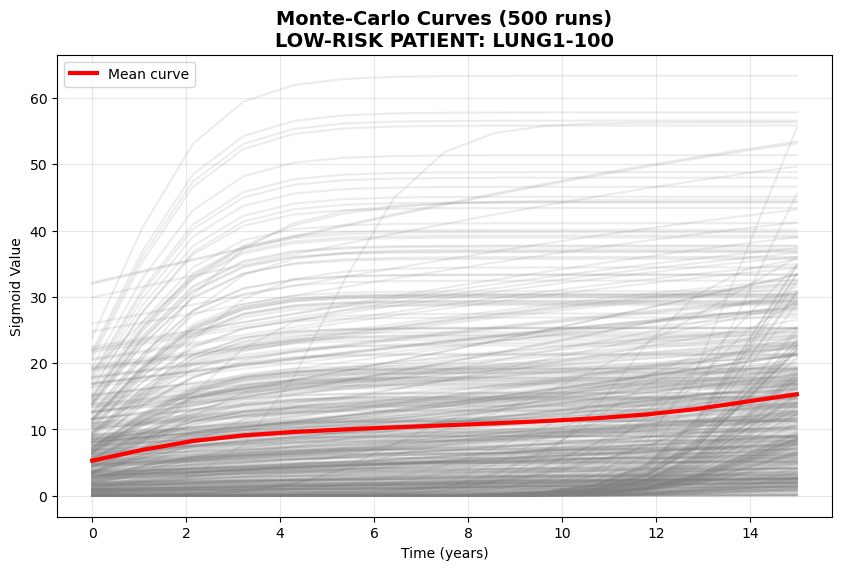

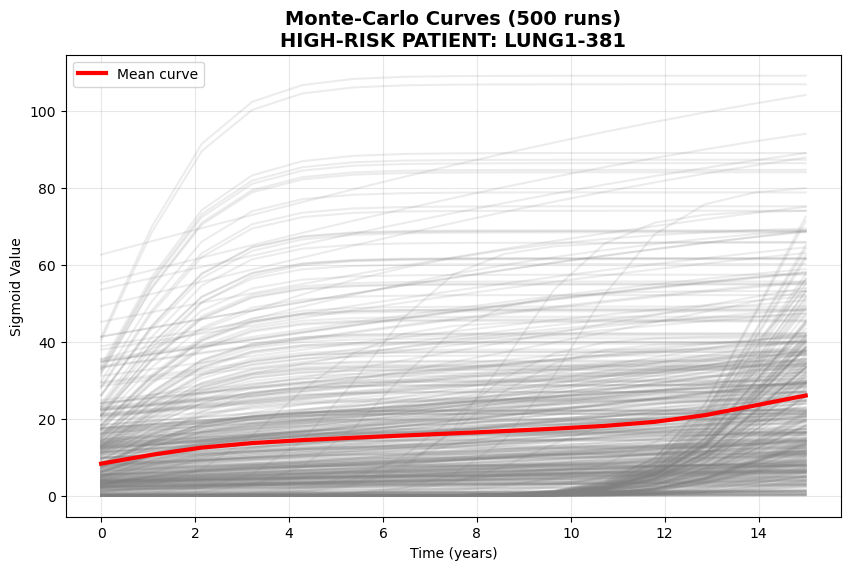


✓ Saved Monte-Carlo plots for LOW and HIGH risk patients.


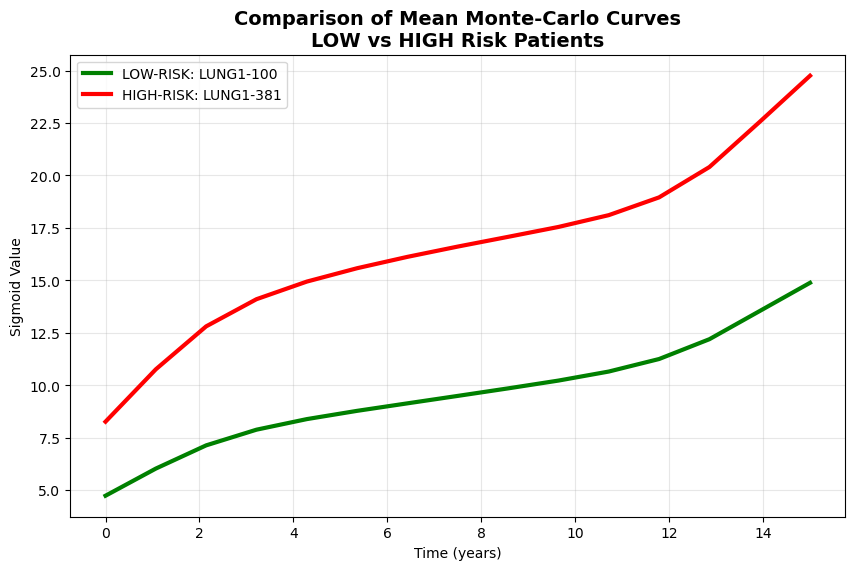

✓ Saved combined mean curve figure → data3d/results/patient_prediction/mean_curves_low_vs_high.png

STEP X: GROUP-LEVEL MC CURVES FOR LOW / MEDIUM / HIGH RISK
   → Group Low: 139 patients
   → Group Medium: 143 patients
   → Group High: 139 patients


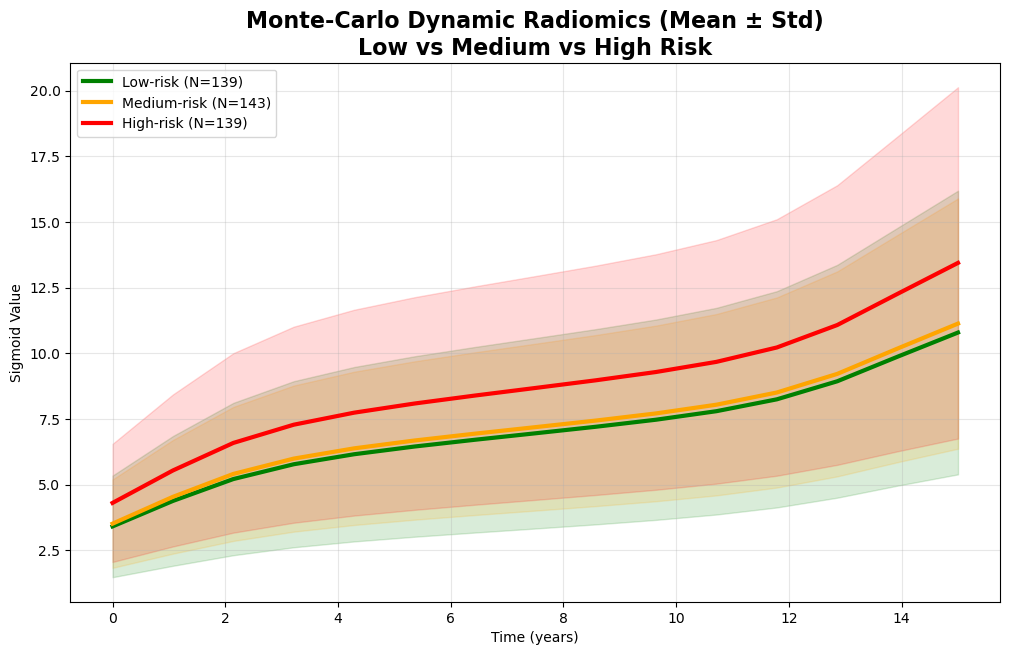


✓ Saved group-level MC comparison → data3d/results/patient_prediction/mc_group_mean_std_all_risk.png


In [6]:
# ============================================================================
# EXTRA STEP: PLOT MONTE-CARLO CURVES FOR LOW-RISK & HIGH-RISK PATIENTS
# ============================================================================

print("\n" + "="*80)
print("STEP X: PLOT MONTE CARLO CURVES FOR LOW-RISK & HIGH-RISK PATIENTS")
print("="*80)

# -----------------------------
# 1. Lấy risk score toàn cohort
# -----------------------------
X_all = cox_data_with_id.drop(columns=["patient_id"])
risk_scores = cph.predict_partial_hazard(X_all)

# -----------------------------
# 2. Xác định low-risk & high-risk
# -----------------------------
idx_low = np.argmin(risk_scores.values)
idx_high = np.argmax(risk_scores.values)

pid_low = patient_ids_cox[idx_low]
pid_high = patient_ids_cox[idx_high]

print(f"LOW-RISK PATIENT  = {pid_low}, index = {idx_low}")
print(f"HIGH-RISK PATIENT = {pid_high}, index = {idx_high}")

# -----------------------------
# 3. Lấy PCA vector cho 2 bệnh nhân
# -----------------------------
pca_low = radiomics_pca[idx_low]
pca_high = radiomics_pca[idx_high]

# -----------------------------
# 4. Hàm vẽ 300 đường MC
# -----------------------------
def plot_mc_curves(pca_vec, patient_id, title, savepath=None):
    t = np.linspace(0, T_MAX, T_MAX)
    curves = []

    # Generate 300 curves giống code gốc
    for i in range(N_MC_RUNS):
        w_L = np.random.randn(len(pca_vec))
        w_k = np.random.randn(len(pca_vec))
        w_t = np.random.randn(len(pca_vec))

        L = abs(np.dot(w_L, pca_vec)) + 1e-3
        k_raw = np.dot(w_k, pca_vec)
        k = 0.1 + 0.9 * (1 / (1 + np.exp(-k_raw)))
        t0_raw = np.dot(w_t, pca_vec)
        t0 = 0.5 + 13.5 * (1 / (1 + np.exp(-t0_raw)))

        S = L / (1 + np.exp(-k * (t - t0)))
        curves.append(S)

    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)

    # -----------------------------
    #          PLOT
    # -----------------------------
    plt.figure(figsize=(10, 6))

    # Plot 300 curves (màu nhạt)
    for c in curves:
        plt.plot(t, c, color='gray', alpha=0.15)

    # Plot mean curve (màu đậm)
    plt.plot(t, mean_curve, color='red', linewidth=3, label="Mean curve")

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Time (years)")
    plt.ylabel("Sigmoid Value")
    plt.legend()
    plt.grid(alpha=0.3)

    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")

    plt.show()


# -----------------------------
# 5. Vẽ hình cho low-risk
# -----------------------------
plot_mc_curves(
    pca_low,
    pid_low,
    title=f"Monte-Carlo Curves (500 runs)\nLOW-RISK PATIENT: {pid_low}",
    savepath=f"{OUTPUT_DIR}/mc_low_{pid_low}.png"
)

# -----------------------------
# 6. Vẽ hình cho high-risk
# -----------------------------
plot_mc_curves(
    pca_high,
    pid_high,
    title=f"Monte-Carlo Curves (500 runs)\nHIGH-RISK PATIENT: {pid_high}",
    savepath=f"{OUTPUT_DIR}/mc_high_{pid_high}.png"
)

print("\n✓ Saved Monte-Carlo plots for LOW and HIGH risk patients.")

# ============================================================================
# EXTRA STEP: PLOT MEAN CURVES OF LOW & HIGH RISK PATIENT IN ONE FIGURE
# ============================================================================

def compute_mc_mean_curve(pca_vec, n_runs=300, T=15):
    """Generate MC curves and return only the mean curve."""
    t = np.linspace(0, T, T)
    curves = []

    for _ in range(n_runs):
        w_L = np.random.randn(len(pca_vec))
        w_k = np.random.randn(len(pca_vec))
        w_t0 = np.random.randn(len(pca_vec))

        L = abs(np.dot(w_L, pca_vec)) + 1e-3
        k_raw = np.dot(w_k, pca_vec)
        k = 0.1 + 0.9 * (1 / (1 + np.exp(-k_raw)))
        t0_raw = np.dot(w_t0, pca_vec)
        t0 = 0.5 + 13.5 * (1 / (1 + np.exp(-t0_raw)))

        S = L / (1 + np.exp(-k * (t - t0)))
        curves.append(S)

    return t, np.mean(curves, axis=0)


# --- Lấy mean curve cho LOW RISK ---
t, mean_low = compute_mc_mean_curve(pca_low, n_runs=N_MC_RUNS, T=T_MAX)

# --- Lấy mean curve cho HIGH RISK ---
_, mean_high = compute_mc_mean_curve(pca_high, n_runs=N_MC_RUNS, T=T_MAX)


# ============================================================================
# PLOT 2 MEAN CURVES TRÊN CÙNG 1 HÌNH
# ============================================================================

plt.figure(figsize=(10,6))

plt.plot(t, mean_low, color='green', linewidth=3, label=f"LOW-RISK: {pid_low}")
plt.plot(t, mean_high, color='red', linewidth=3, label=f"HIGH-RISK: {pid_high}")

plt.title("Comparison of Mean Monte-Carlo Curves\nLOW vs HIGH Risk Patients",
          fontsize=14, fontweight='bold')
plt.xlabel("Time (years)")
plt.ylabel("Sigmoid Value")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(f"{OUTPUT_DIR}/mean_curves_low_vs_high.png",
            dpi=200, bbox_inches="tight")
plt.show()

print(f"✓ Saved combined mean curve figure → {OUTPUT_DIR}/mean_curves_low_vs_high.png")

# ============================================================================
# EXTRA STEP: GROUP-LEVEL MONTE-CARLO MEAN ± STD FOR LOW / MEDIUM / HIGH RISK
# ============================================================================

print("\n" + "="*80)
print("STEP X: GROUP-LEVEL MC CURVES FOR LOW / MEDIUM / HIGH RISK")
print("="*80)

# ----------------------------------------------------------------------
# 1. Tính risk score cho toàn cohort
# ----------------------------------------------------------------------
X_all = cox_data_with_id.drop(columns=["patient_id"])
risk_scores = cph.predict_partial_hazard(X_all)

# Xác định nhóm theo tertile 33% - 67%
t33 = risk_scores.quantile(0.33)
t67 = risk_scores.quantile(0.67)

group_labels = []
for r in risk_scores:
    if r <= t33:
        group_labels.append("Low")
    elif r <= t67:
        group_labels.append("Medium")
    else:
        group_labels.append("High")

group_labels = np.array(group_labels)

# ----------------------------------------------------------------------
# 2. Hàm tính mean + std của các đường MC cho MỘT BỆNH NHÂN
# ----------------------------------------------------------------------
def mc_curve(pca_vec, n_runs=300, T=15):
    t = np.linspace(0, T, T)
    curves = []

    for _ in range(n_runs):
        w_L = np.random.randn(len(pca_vec))
        w_k = np.random.randn(len(pca_vec))
        w_t = np.random.randn(len(pca_vec))

        L = abs(np.dot(w_L, pca_vec)) + 1e-3
        k_raw = np.dot(w_k, pca_vec)
        k = 0.1 + 0.9 * (1 / (1 + np.exp(-k_raw)))
        t0_raw = np.dot(w_t, pca_vec)
        t0 = 0.5 + 13.5 * (1 / (1 + np.exp(-t0_raw)))

        S = L / (1 + np.exp(-k * (t - t0)))
        curves.append(S)

    return np.array(curves)   # shape = [300, T]


# ----------------------------------------------------------------------
# 3. Hàm tính mean curve & std curve CHO MỘT NHÓM (Low, Medium, High)
# ----------------------------------------------------------------------
def mc_group_mean_std(pca_matrix, indices, group_name):
    """
    pca_matrix: radiomics_pca (N × PCA_dim)
    indices: danh sách index bệnh nhân trong nhóm
    """
    if len(indices) == 0:
        print(f"⚠ Nhóm {group_name} rỗng!")
        return None, None

    print(f"   → Group {group_name}: {len(indices)} patients")

    all_curves = []

    for idx in indices:
        curves = mc_curve(pca_matrix[idx], n_runs=N_MC_RUNS, T=T_MAX)
        mean_curve = curves.mean(axis=0)
        all_curves.append(mean_curve)

    all_curves = np.array(all_curves)   # shape = [n_patients_in_group, T]
    
    group_mean = all_curves.mean(axis=0)
    group_std = all_curves.std(axis=0)

    return group_mean, group_std


# ----------------------------------------------------------------------
# 4. Tính mean ± std cho cả 3 nhóm
# ----------------------------------------------------------------------
idx_low = np.where(group_labels == "Low")[0]
idx_med = np.where(group_labels == "Medium")[0]
idx_high = np.where(group_labels == "High")[0]

t = np.linspace(0, T_MAX, T_MAX)

mean_low, std_low = mc_group_mean_std(radiomics_pca, idx_low, "Low")
mean_med, std_med = mc_group_mean_std(radiomics_pca, idx_med, "Medium")
mean_high, std_high = mc_group_mean_std(radiomics_pca, idx_high, "High")


# ----------------------------------------------------------------------
# 5. VẼ TẤT CẢ TRONG MỘT HÌNH
# ----------------------------------------------------------------------
plt.figure(figsize=(12, 7))

# LOW
plt.plot(t, mean_low, color="green", linewidth=3, label=f"Low-risk (N={len(idx_low)})")
plt.fill_between(t, mean_low - std_low, mean_low + std_low,
                 color="green", alpha=0.15)

# MEDIUM
plt.plot(t, mean_med, color="orange", linewidth=3, label=f"Medium-risk (N={len(idx_med)})")
plt.fill_between(t, mean_med - std_med, mean_med + std_med,
                 color="orange", alpha=0.15)

# HIGH
plt.plot(t, mean_high, color="red", linewidth=3, label=f"High-risk (N={len(idx_high)})")
plt.fill_between(t, mean_high - std_high, mean_high + std_high,
                 color="red", alpha=0.15)

plt.title("Monte-Carlo Dynamic Radiomics (Mean ± Std)\nLow vs Medium vs High Risk",
          fontsize=16, fontweight="bold")
plt.xlabel("Time (years)")
plt.ylabel("Sigmoid Value")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(f"{OUTPUT_DIR}/mc_group_mean_std_all_risk.png",
            dpi=250, bbox_inches="tight")
plt.show()

print(f"\n✓ Saved group-level MC comparison → {OUTPUT_DIR}/mc_group_mean_std_all_risk.png")



╔═══════════════════════════════════════════════════════════════════════════════╗
║         INDIVIDUAL PATIENT RISK PREDICTION & INTERPRETATION                  ║
║              Cox Model: 50 PCA + 20 Dynamic Features                         ║
║              BINARY CLASSIFICATION: LOW RISK vs HIGH RISK                    ║
╚═══════════════════════════════════════════════════════════════════════════════╝

STEP 1: LOADING DATA

📂 Radiomics: data3d/outputs/features_normalized_standard.npy
   Shape: (421, 443)
📂 Clinical: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv

STEP 2: PATIENT ID MATCHING

🔍 Matching patients...
✓ Matched 421 patients
✅ DATA SUMMARY:
   Patients: 421
   Events: 373

STEP 3: APPLY PCA - 443 → 50 COMPONENTS

⚙️  Applying PCA...
✓ PCA: (421, 443) → (421, 200)
   Variance explained: 99.98%

STEP 4: GENERATE DYNAMIC FEATURES FROM PCA
✓ Generated: (421, 20)

STEP 5: TRAIN BEST MODEL (50 PCA + 20 DYNAMIC)

⚙️  Training Cox model...
✓ C-Index: 0.7534
  Feature

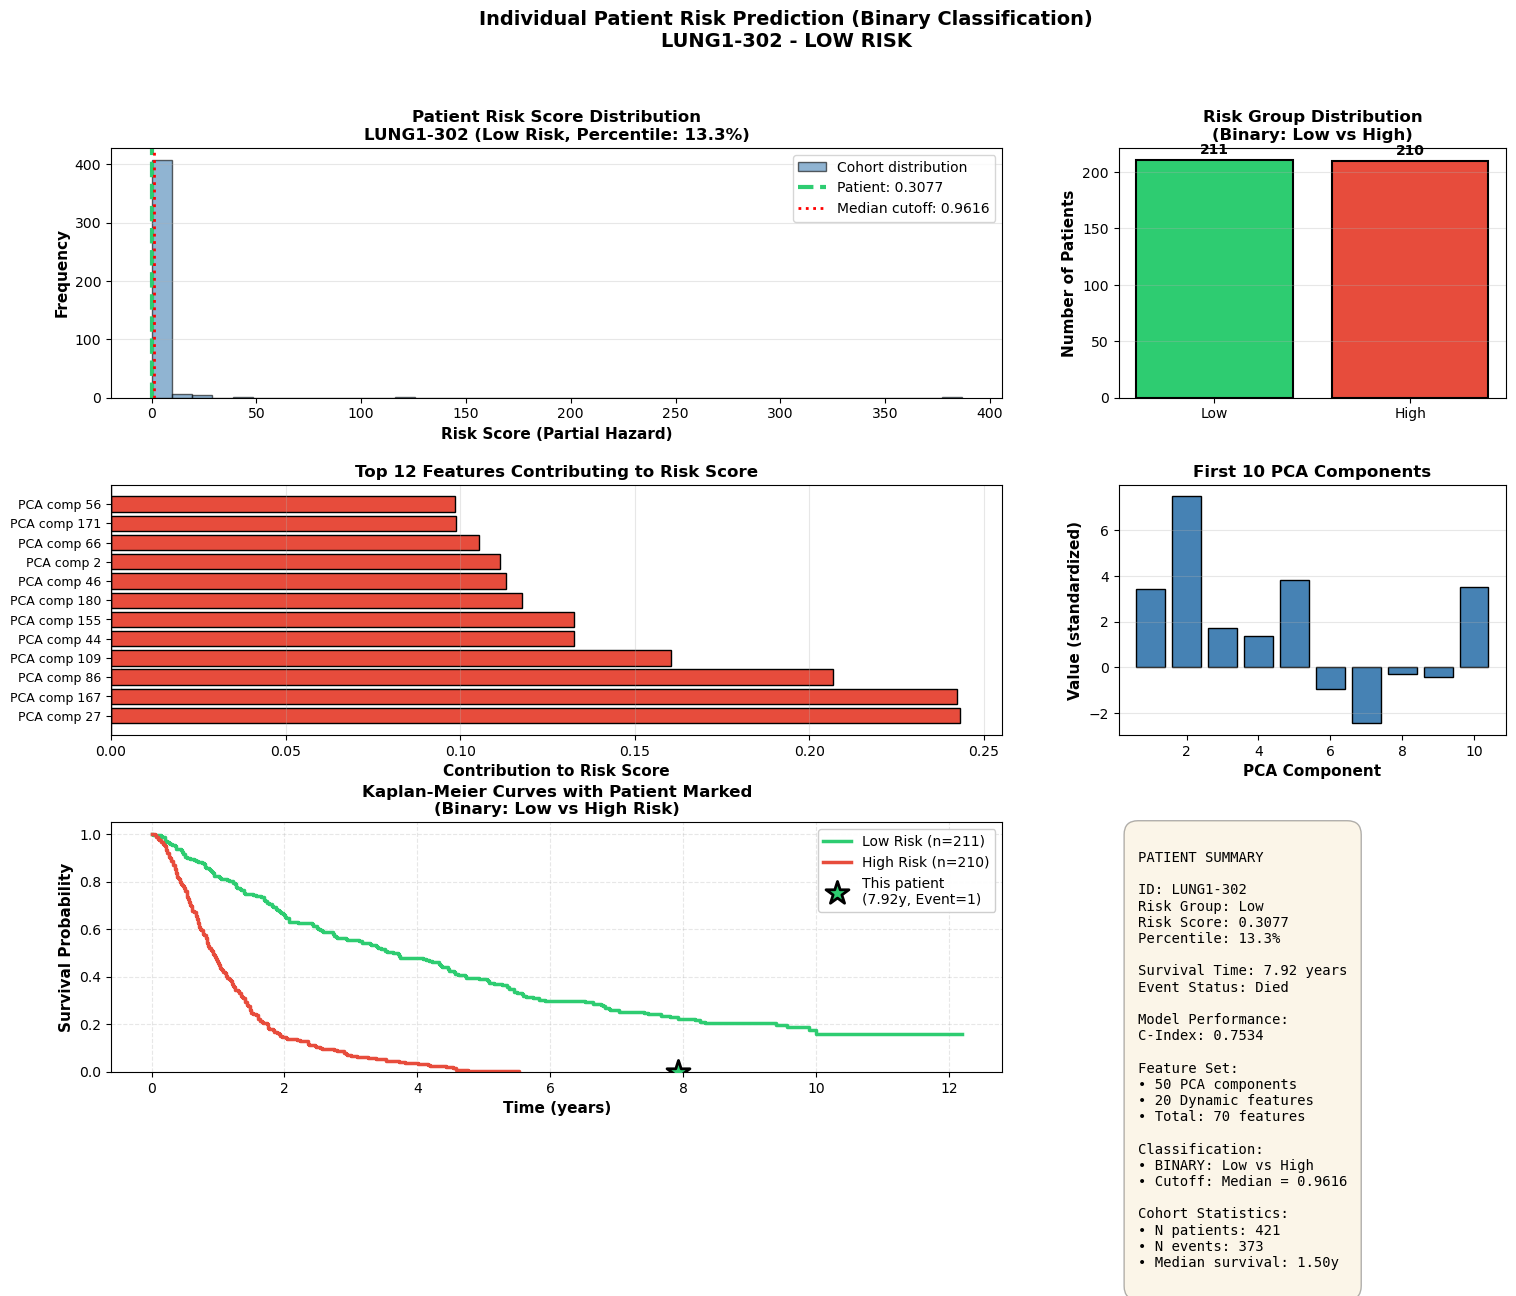


STEP 10: SAVE DETAILED REPORT
✓ Report saved: data3d/results/patient_prediction/patient_report_LUNG1-302.json

🎯 INTERPRETATION & CLINICAL IMPLICATIONS (BINARY CLASSIFICATION)

╔═══════════════════════════════════════════════════════════════════════════════╗
║                   PATIENT: LUNG1-302                             ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  RISK ASSESSMENT (BINARY CLASSIFICATION):                                    ║
║  ────────────────────────────────────────                                    ║
║  • Risk Group: LOW RISK                                                ║
║  • Risk Score: 0.3077 (Percentile: 13.3%)                               ║
║  • Median Cutoff: 0.9616                                                ║
║  • Classification: Score ≤ median → Low Risk                      ║
║                                               

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Individual Patient Risk Prediction & Interpretation
===================================================

Dự đoán rủi ro cho một bệnh nhân và giải thích:
1. Risk score từ Cox model
2. Survival prediction
3. Feature contributions
4. So sánh với cohort

CHỈ PHÂN TÍCH LOW RISK VÀ HIGH RISK (2 NHÓM)

Author: Paul
Date: 2025-11-18
Modified: 2025-11-21
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple
import warnings

from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║         INDIVIDUAL PATIENT RISK PREDICTION & INTERPRETATION                  ║
║              Cox Model: 50 PCA + 20 Dynamic Features                         ║
║              BINARY CLASSIFICATION: LOW RISK vs HIGH RISK                    ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

# ============================================================================
# CONFIGURATION
# ============================================================================

RANDOM_SEED = 42
N_MC_RUNS = 500
T_MAX = 15
N_PCA_COMPONENTS = 200
OUTPUT_DIR = 'data3d/results/patient_prediction'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def days_to_years(days: float) -> float:
    """Chuyển đổi ngày → năm."""
    if pd.isna(days):
        return np.nan
    return days / 365.25


def sigmoid(t: np.ndarray, L: float, k: float, t0: float) -> np.ndarray:
    """Sigmoid function."""
    return L / (1 + np.exp(-k * (t - t0)))


def monte_carlo_from_pca(pca_vector: np.ndarray,
                         n_runs: int = 500,
                         T: int = 15,
                         seed: int = None) -> dict:
    """Generate 20 dynamic features from PCA vector."""
    if seed is not None:
        np.random.seed(seed)

    x = pca_vector
    t = np.linspace(0, T, T)
    curves = []

    for _ in range(n_runs):
        w_L = np.random.randn(len(x))
        w_k = np.random.randn(len(x))
        w_t0 = np.random.randn(len(x))

        L = np.dot(w_L, x)
        L = abs(L) + 1e-3

        k_raw = np.dot(w_k, x)
        k = 0.1 + 0.9 * (1 / (1 + np.exp(-k_raw)))

        t0_raw = np.dot(w_t0, x)
        t0 = 0.5 + 13.5 * (1 / (1 + np.exp(-t0_raw)))

        S = sigmoid(t, L, k, t0)
        curves.append(S)

    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)
    gradient = np.gradient(mean_curve)

    auc = np.trapz(mean_curve, t)
    slope = np.max(gradient)

    half_max = 0.5 * mean_curve.max()
    time_half_idx = np.argmax(mean_curve >= half_max)
    time_half = t[time_half_idx] if time_half_idx > 0 else 0

    peak_idx = np.argmax(gradient)
    peak = mean_curve[peak_idx]

    uncertainty = std_curve.mean()
    curve_min = mean_curve.min()
    curve_max = mean_curve.max()
    curve_range = curve_max - curve_min
    curve_mean = mean_curve.mean()
    curve_median = np.median(mean_curve)
    curve_std = mean_curve.std()

    mean_grad = gradient.mean()
    max_grad = gradient.max()
    min_grad = gradient.min()
    std_grad = gradient.std()

    mid_idx = T // 3
    late_idx = 2 * T // 3

    auc_early = np.trapz(mean_curve[:mid_idx], t[:mid_idx])
    auc_mid = np.trapz(mean_curve[mid_idx:late_idx], t[mid_idx:late_idx])
    auc_late = np.trapz(mean_curve[late_idx:], t[late_idx:])
    uncertainty_variance = std_curve.var()

    curve_centered = mean_curve - curve_mean
    if curve_std > 1e-6:
        skewness = (curve_centered ** 3).mean() / (curve_std ** 3)
    else:
        skewness = 0.0

    return {
        "auc": auc, "slope": slope, "time_half": time_half, "peak": peak,
        "uncertainty": uncertainty, "curve_min": curve_min, "curve_max": curve_max,
        "curve_range": curve_range, "curve_mean": curve_mean,
        "curve_median": curve_median, "curve_std": curve_std,
        "mean_grad": mean_grad, "max_grad": max_grad, "min_grad": min_grad,
        "std_grad": std_grad, "auc_early": auc_early, "auc_mid": auc_mid,
        "auc_late": auc_late, "uncertainty_variance": uncertainty_variance,
        "skewness": skewness,
    }


def generate_dynamic_from_pca(pca_features: np.ndarray,
                              n_runs: int = 500,
                              T: int = 15) -> pd.DataFrame:
    """Generate 20 dynamic features for patients from PCA."""
    n_patients = pca_features.shape[0]
    dynamic_features = []

    for i in range(n_patients):
        pca_vector = pca_features[i]
        result = monte_carlo_from_pca(pca_vector, n_runs=n_runs, T=T, seed=42 + i)
        dynamic_features.append([
            result["auc"], result["slope"], result["time_half"], result["peak"],
            result["uncertainty"], result["curve_min"], result["curve_max"],
            result["curve_range"], result["curve_mean"], result["curve_median"],
            result["curve_std"], result["mean_grad"], result["max_grad"],
            result["min_grad"], result["std_grad"], result["auc_early"],
            result["auc_mid"], result["auc_late"], result["uncertainty_variance"],
            result["skewness"],
        ])

    df = pd.DataFrame(dynamic_features, columns=[
        "dynamic_auc", "dynamic_slope", "dynamic_time_half", "dynamic_peak",
        "dynamic_uncertainty", "dynamic_min", "dynamic_max", "dynamic_range",
        "dynamic_mean", "dynamic_median", "dynamic_std", "dynamic_mean_grad",
        "dynamic_max_grad", "dynamic_min_grad", "dynamic_std_grad",
        "dynamic_auc_early", "dynamic_auc_mid", "dynamic_auc_late",
        "dynamic_uncertainty_var", "dynamic_skewness"
    ])
    return df


# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================

print("="*80)
print("STEP 1: LOADING DATA")
print("="*80)

features_path = 'data3d/outputs/features_normalized_standard.npy'
if not os.path.exists(features_path):
    features_path = 'data3d/outputs/radiomic_features_440.npy'

print(f"\n📂 Radiomics: {features_path}")
radiomics_features_all = np.load(features_path)
print(f"   Shape: {radiomics_features_all.shape}")

names_path = 'data3d/outputs/feature_names_normalized_standard.json'
with open(names_path, 'r') as f:
    feature_names = json.load(f)

ids_path = 'data3d/outputs/patient_ids.json'
with open(ids_path, 'r') as f:
    patient_ids_all = json.load(f)

clinical_paths = [
    "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
    "NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
]

clinical_data = None
for path in clinical_paths:
    if os.path.exists(path):
        clinical_data = pd.read_csv(path)
        print(f"📂 Clinical: {path}")
        break

if clinical_data is None:
    raise FileNotFoundError("Clinical data not found!")

# ============================================================================
# STEP 2: PATIENT ID MATCHING
# ============================================================================

print("\n" + "="*80)
print("STEP 2: PATIENT ID MATCHING")
print("="*80)

patient_id_col = None
for col in clinical_data.columns:
    if 'patient' in col.lower() and 'id' in col.lower():
        patient_id_col = col
        break

if patient_id_col is None:
    clinical_data['PatientID'] = clinical_data.index.astype(str)
    patient_id_col = 'PatientID'

clinical_data['PatientID_str'] = clinical_data[patient_id_col].astype(str)
patient_ids_radiomics = [str(pid) for pid in patient_ids_all]

time_col = [c for c in clinical_data.columns if 'survival.time' in c.lower()][0]
event_col = [c for c in clinical_data.columns if 'event' in c.lower() or 'deadstatus' in c.lower()][0]

print("\n🔍 Matching patients...")
matched_data = []

for i, pid in enumerate(patient_ids_radiomics):
    clinical_row = clinical_data[clinical_data['PatientID_str'] == pid]

    if len(clinical_row) == 0:
        if i < len(clinical_data):
            clinical_row = clinical_data.iloc[[i]]
        else:
            continue

    if len(clinical_row) == 0:
        continue

    time_days = clinical_row[time_col].values[0]
    event = clinical_row[event_col].values[0]

    if pd.isna(time_days) or pd.isna(event):
        continue

    time_years = days_to_years(time_days)
    radiomics_vector = radiomics_features_all[i]

    matched_data.append({
        'patient_id': pid,
        'time_years': time_years,
        'event': event,
        'radiomics_vector': radiomics_vector
    })

print(f"✓ Matched {len(matched_data)} patients")

radiomics_features = np.array([d['radiomics_vector'] for d in matched_data])
patient_ids = [d['patient_id'] for d in matched_data]
survival_data = {
    'time': np.array([d['time_years'] for d in matched_data]),
    'event': np.array([d['event'] for d in matched_data])
}

print(f"✅ DATA SUMMARY:")
print(f"   Patients: {len(matched_data)}")
print(f"   Events: {int(survival_data['event'].sum())}")

# ============================================================================
# STEP 3: APPLY PCA
# ============================================================================

print("\n" + "="*80)
print("STEP 3: APPLY PCA - 443 → 50 COMPONENTS")
print("="*80)

scaler_radiomics = StandardScaler()
radiomics_scaled = scaler_radiomics.fit_transform(radiomics_features)

print(f"\n⚙️  Applying PCA...")
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
radiomics_pca = pca.fit_transform(radiomics_scaled)

explained_var = pca.explained_variance_ratio_.sum()
print(f"✓ PCA: {radiomics_scaled.shape} → {radiomics_pca.shape}")
print(f"   Variance explained: {explained_var:.2%}")

# ============================================================================
# STEP 4: GENERATE DYNAMIC FEATURES FROM PCA
# ============================================================================

print("\n" + "="*80)
print("STEP 4: GENERATE DYNAMIC FEATURES FROM PCA")
print("="*80)

dynamic_from_pca_df = generate_dynamic_from_pca(radiomics_pca, n_runs=N_MC_RUNS, T=T_MAX)

scaler_dynamic = StandardScaler()
dynamic_pca_scaled = scaler_dynamic.fit_transform(dynamic_from_pca_df)
dynamic_pca_scaled_df = pd.DataFrame(dynamic_pca_scaled, columns=dynamic_from_pca_df.columns)

print(f"✓ Generated: {dynamic_pca_scaled_df.shape}")

# ============================================================================
# STEP 5: TRAIN BEST MODEL (50 PCA + 20 DYNAMIC)
# ============================================================================

print("\n" + "="*80)
print("STEP 5: TRAIN BEST MODEL (50 PCA + 20 DYNAMIC)")
print("="*80)

pca_df = pd.DataFrame(radiomics_pca, columns=[f"PCA_comp_{i+1}" for i in range(N_PCA_COMPONENTS)])

cox_data_with_id = pd.concat([
    pca_df.reset_index(drop=True),
    dynamic_pca_scaled_df.reset_index(drop=True),
    pd.DataFrame({
        'time': survival_data['time'],
        'event': survival_data['event'],
        'patient_id': patient_ids
    }).reset_index(drop=True)
], axis=1).dropna()

cox_data_with_id = cox_data_with_id.reset_index(drop=True)

patient_ids_cox = cox_data_with_id['patient_id'].values
cox_data = cox_data_with_id.drop('patient_id', axis=1)

print(f"\n⚙️  Training Cox model...")
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_data, duration_col='time', event_col='event', show_progress=False)

c_index = cph.concordance_index_
print(f"✓ C-Index: {c_index:.4f}")
print(f"  Features: {cox_data.shape[1] - 2}")
print(f"  Patients in model: {cox_data.shape[0]}")

# ============================================================================
# STEP 6: SELECT A RANDOM PATIENT
# ============================================================================

print("\n" + "="*80)
print("STEP 6: SELECT INDIVIDUAL PATIENT")
print("="*80)

# Chọn một bệnh nhân ngẫu nhiên từ những người có đầy đủ dữ liệu
# patient_idx = np.random.randint(0, len(cox_data_with_id))
patient_idx = 300
selected_patient_id = patient_ids_cox[patient_idx]

print(f"\n👤 Selected Patient: {selected_patient_id}")
print(f"   Index in cohort: {patient_idx} / {len(cox_data_with_id)}")

# Lấy dữ liệu của bệnh nhân
selected_row = cox_data.iloc[patient_idx]
selected_time = selected_row['time']
selected_event = selected_row['event']

print(f"\n📊 Clinical Data:")
print(f"   Survival time: {selected_time:.2f} years")
print(f"   Event status: {'Died (1)' if selected_event == 1 else 'Censored (0)'}")

# ============================================================================
# STEP 7: CALCULATE RISK SCORE (BINARY: LOW vs HIGH)
# ============================================================================

print("\n" + "="*80)
print("STEP 7: CALCULATE RISK SCORE (BINARY CLASSIFICATION)")
print("="*80)

# Lấy features của bệnh nhân (drop time/event)
patient_features = selected_row.drop(['time', 'event']).to_frame().T

# Tính risk score
risk_score = cph.predict_partial_hazard(patient_features).values[0]

# So sánh với cohort
all_risk_scores = cph.predict_partial_hazard(cox_data.drop(['time', 'event'], axis=1))
percentile = (all_risk_scores <= risk_score).mean() * 100

print(f"\n🎯 Risk Score: {risk_score:.4f}")
print(f"   Cohort median: {all_risk_scores.median():.4f}")
print(f"   Cohort mean: {all_risk_scores.mean():.4f}")
print(f"   Percentile: {percentile:.1f}%")

# *** THAY ĐỔI: Xác định risk group theo MEDIAN (2 nhóm thay vì 3) ***
median_score = all_risk_scores.median()

if risk_score <= median_score:
    risk_group = 'Low'
    risk_color = '#2ecc71'
else:
    risk_group = 'High'
    risk_color = '#e74c3c'

print(f"\n📊 Risk Group: {risk_group} (Binary Classification)")
print(f"   Median cutoff: {median_score:.4f}")
print(f"   Classification: {'≤ median → Low Risk' if risk_score <= median_score else '> median → High Risk'}")

# ============================================================================
# STEP 8: FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("STEP 8: FEATURE IMPORTANCE (TOP CONTRIBUTING FEATURES)")
print("="*80)

# Lấy coefficients từ Cox model
cox_coef = cph.params_.sort_values(ascending=False)

# Tính contribution = coefficient × feature_value
contributions = cox_coef * patient_features.iloc[0]
contributions_sorted = contributions.sort_values(ascending=False)

print(f"\n🔝 Top 10 Most Important Features:")
print(f"{'Rank':<5} {'Feature':<25} {'Coef':<10} {'Value':<10} {'Contribution':<12}")
print("-" * 62)

for rank, (feat, contrib) in enumerate(contributions_sorted.head(10).items(), 1):
    coef = cox_coef[feat]
    val = patient_features[feat].values[0]
    print(f"{rank:<5} {feat:<25} {coef:>9.4f} {val:>9.4f} {contrib:>11.4f}")

print(f"\n📉 Top 10 Most Protective Features:")
print(f"{'Rank':<5} {'Feature':<25} {'Coef':<10} {'Value':<10} {'Contribution':<12}")
print("-" * 62)

for rank, (feat, contrib) in enumerate(contributions_sorted.tail(10).iloc[::-1].items(), 1):
    coef = cox_coef[feat]
    val = patient_features[feat].values[0]
    print(f"{rank:<5} {feat:<25} {coef:>9.4f} {val:>9.4f} {contrib:>11.4f}")

# ============================================================================
# STEP 9: VISUALIZATIONS (BINARY: LOW vs HIGH)
# ============================================================================

print("\n" + "="*80)
print("STEP 9: CREATE VISUALIZATIONS (BINARY CLASSIFICATION)")
print("="*80)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# ─────────────────────────────────────────────────────────────────────────
# Plot 1: Risk Score vs Cohort Distribution
# ─────────────────────────────────────────────────────────────────────────

ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(all_risk_scores, bins=40, alpha=0.6, color='steelblue', edgecolor='black', label='Cohort distribution')
ax1.axvline(risk_score, color=risk_color, linewidth=3, linestyle='--', label=f'Patient: {risk_score:.4f}')
ax1.axvline(median_score, color='red', linewidth=2, linestyle=':', label=f'Median cutoff: {median_score:.4f}')
ax1.set_xlabel('Risk Score (Partial Hazard)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title(f'Patient Risk Score Distribution\n{selected_patient_id} ({risk_group} Risk, Percentile: {percentile:.1f}%)',
              fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────────────────
# Plot 2: Risk Group Comparison (2 nhóm)
# ─────────────────────────────────────────────────────────────────────────

ax2 = fig.add_subplot(gs[0, 2])
risk_groups_all = np.array(['Low' if x <= median_score else 'High' for x in all_risk_scores])
group_counts = pd.Series(risk_groups_all).value_counts()
colors_bar = ['#2ecc71', '#e74c3c']
# Đảm bảo thứ tự Low, High
group_order = ['Low', 'High']
group_counts = group_counts.reindex(group_order)
ax2.bar(group_counts.index, group_counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Patients', fontsize=11, fontweight='bold')
ax2.set_title('Risk Group Distribution\n(Binary: Low vs High)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for i, (group, count) in enumerate(group_counts.items()):
    ax2.text(i, count + 5, str(count), ha='center', fontsize=10, fontweight='bold')

# ─────────────────────────────────────────────────────────────────────────
# Plot 3: Top Contributing Features (Positive)
# ─────────────────────────────────────────────────────────────────────────

ax3 = fig.add_subplot(gs[1, :2])
top_features = contributions_sorted.head(12)
colors_feat = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_features.values]
ax3.barh(range(len(top_features)), top_features.values, color=colors_feat, edgecolor='black', linewidth=1)
ax3.set_yticks(range(len(top_features)))
ax3.set_yticklabels([f.replace('_', ' ') for f in top_features.index], fontsize=9)
ax3.set_xlabel('Contribution to Risk Score', fontsize=11, fontweight='bold')
ax3.set_title('Top 12 Features Contributing to Risk Score', fontsize=12, fontweight='bold')
ax3.axvline(0, color='black', linewidth=1, linestyle='-')
ax3.grid(True, alpha=0.3, axis='x')

# ─────────────────────────────────────────────────────────────────────────
# Plot 4: PCA Component Values
# ─────────────────────────────────────────────────────────────────────────

ax4 = fig.add_subplot(gs[1, 2])
pca_values = patient_features[[f'PCA_comp_{i+1}' for i in range(N_PCA_COMPONENTS)]].values.flatten()
ax4.bar(range(1, 11), pca_values[:10], color='steelblue', edgecolor='black', linewidth=1)
ax4.set_xlabel('PCA Component', fontsize=11, fontweight='bold')
ax4.set_ylabel('Value (standardized)', fontsize=11, fontweight='bold')
ax4.set_title('First 10 PCA Components', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────────────────
# Plot 5: Kaplan-Meier with Patient Marked (2 nhóm)
# ─────────────────────────────────────────────────────────────────────────

ax5 = fig.add_subplot(gs[2, :2])

kmf = KaplanMeierFitter()
colors_km = {'Low': '#2ecc71', 'High': '#e74c3c'}
risk_order = ['Low', 'High']

for group in risk_order:
    mask = risk_groups_all == group
    kmf.fit(
        cox_data[mask]['time'].values,
        cox_data[mask]['event'].values,
        label=f'{group} Risk (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax5, ci_show=False, color=colors_km[group], linewidth=2.5)

# Mark patient's position
ax5.scatter([selected_time], [1.0 if selected_event == 0 else 0.0],
           s=300, color=risk_color, marker='*', edgecolor='black', linewidth=2,
           zorder=10, label=f'This patient\n({selected_time:.2f}y, Event={int(selected_event)})')

ax5.set_xlabel('Time (years)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Survival Probability', fontsize=11, fontweight='bold')
ax5.set_title('Kaplan-Meier Curves with Patient Marked\n(Binary: Low vs High Risk)', fontsize=12, fontweight='bold')
ax5.legend(loc='best', fontsize=10, framealpha=0.95)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_ylim([0, 1.05])

# ─────────────────────────────────────────────────────────────────────────
# Plot 6: Summary Statistics Box
# ─────────────────────────────────────────────────────────────────────────

ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')

summary_text = f"""
PATIENT SUMMARY

ID: {selected_patient_id}
Risk Group: {risk_group}
Risk Score: {risk_score:.4f}
Percentile: {percentile:.1f}%

Survival Time: {selected_time:.2f} years
Event Status: {'Died' if selected_event == 1 else 'Censored'}

Model Performance:
C-Index: {c_index:.4f}

Feature Set:
• 50 PCA components
• 20 Dynamic features
• Total: 70 features

Classification:
• BINARY: Low vs High
• Cutoff: Median = {median_score:.4f}

Cohort Statistics:
• N patients: {len(cox_data)}
• N events: {int(cox_data['event'].sum())}
• Median survival: {cox_data['time'].median():.2f}y
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3, pad=1))

plt.suptitle(f'Individual Patient Risk Prediction (Binary Classification)\n{selected_patient_id} - {risk_group.upper()} RISK',
            fontsize=14, fontweight='bold', y=0.995)

plt.savefig(os.path.join(OUTPUT_DIR, f'patient_prediction_{selected_patient_id}.png'),
           dpi=300, bbox_inches='tight')
print(f"\n✓ Figure saved: {OUTPUT_DIR}/patient_prediction_{selected_patient_id}.png")

plt.show()

# ============================================================================
# STEP 10: SAVE DETAILED REPORT
# ============================================================================

print("\n" + "="*80)
print("STEP 10: SAVE DETAILED REPORT")
print("="*80)

report = {
    'patient_id': selected_patient_id,
    'model': {
        'type': 'Cox Proportional Hazards',
        'features': '50 PCA + 20 Dynamic',
        'c_index': float(c_index),
        'penalizer': 0.1,
        'classification': 'Binary (Low vs High)'
    },
    'patient_data': {
        'survival_time_years': float(selected_time),
        'event_status': int(selected_event),
        'event_interpretation': 'Died' if selected_event == 1 else 'Censored/Alive'
    },
    'risk_assessment': {
        'risk_score': float(risk_score),
        'risk_group': risk_group,
        'percentile': float(percentile),
        'median_cutoff': float(median_score),
        'cohort_median_score': float(all_risk_scores.median()),
        'cohort_mean_score': float(all_risk_scores.mean()),
        'cohort_std_score': float(all_risk_scores.std())
    },
    'cohort_statistics': {
        'total_patients': int(len(cox_data)),
        'total_events': int(cox_data['event'].sum()),
        'median_survival_years': float(cox_data['time'].median()),
        'event_rate': float(cox_data['event'].sum() / len(cox_data)),
        'n_low_risk': int((risk_groups_all == 'Low').sum()),
        'n_high_risk': int((risk_groups_all == 'High').sum())
    },
    'top_10_contributing_features': {
        feat: {
            'coefficient': float(cox_coef[feat]),
            'patient_value': float(patient_features[feat].values[0]),
            'contribution': float(contrib)
        }
        for feat, contrib in contributions_sorted.head(10).items()
    },
    'top_10_protective_features': {
        feat: {
            'coefficient': float(cox_coef[feat]),
            'patient_value': float(patient_features[feat].values[0]),
            'contribution': float(contrib)
        }
        for feat, contrib in contributions_sorted.tail(10).iloc[::-1].items()
    }
}

report_path = os.path.join(OUTPUT_DIR, f'patient_report_{selected_patient_id}.json')
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

print(f"✓ Report saved: {report_path}")

# ============================================================================
# FINAL INTERPRETATION (BINARY CLASSIFICATION)
# ============================================================================

print("\n" + "="*80)
print("🎯 INTERPRETATION & CLINICAL IMPLICATIONS (BINARY CLASSIFICATION)")
print("="*80)

# Tính số năm sống sót trung bình theo risk group
median_surv_by_group = {}
for group in risk_order:
    mask = risk_groups_all == group
    med = cox_data[mask]['time'].median()
    median_surv_by_group[group] = med

n_low = (risk_groups_all == 'Low').sum()
n_high = (risk_groups_all == 'High').sum()

print(f"""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                   PATIENT: {selected_patient_id}                             ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║                                                                               ║
║  RISK ASSESSMENT (BINARY CLASSIFICATION):                                    ║
║  ────────────────────────────────────────                                    ║
║  • Risk Group: {risk_group.upper()} RISK                                                ║
║  • Risk Score: {risk_score:.4f} (Percentile: {percentile:.1f}%)                               ║
║  • Median Cutoff: {median_score:.4f}                                                ║
║  • Classification: {'Score ≤ median → Low Risk' if risk_score <= median_score else 'Score > median → High Risk'}                      ║
║                                                                               ║
║  CLINICAL OUTCOME:                                                           ║
║  ────────────────                                                            ║
║  • Follow-up time: {selected_time:.2f} years                                           ║
║  • Outcome: {'Died (Event=1)' if selected_event == 1 else 'Censored/Alive (Event=0)'}                                    ║
║                                                                               ║
║  RISK GROUP PROGNOSIS (Median Survival):                                     ║
║  ──────────────────────────────────────                                      ║
║  • Low Risk:  {median_surv_by_group['Low']:.2f} years (n={n_low} patients)                              ║
║  • High Risk: {median_surv_by_group['High']:.2f} years (n={n_high} patients)                              ║
║                                                                               ║
║  This patient's prognosis: {median_surv_by_group[risk_group]:.2f} years median survival                  ║
║                            (similar to {risk_group.lower()} risk group)                       ║
║                                                                               ║
║  TOP 3 RISK FACTORS (promoting higher risk):                                 ║
║  ──────────────────────────────────────────                                  ║
""")

for rank, (feat, contrib) in enumerate(contributions_sorted.head(3).items(), 1):
    coef = cox_coef[feat]
    val = patient_features[feat].values[0]
    direction = "🔴 INCREASES" if coef > 0 else "🟢 DECREASES"
    print(f"║  {rank}. {feat:<30} {direction:15} risk             ║")

print(f"""
║                                                                               ║
║  TOP 3 PROTECTIVE FACTORS (promoting better survival):                      ║
║  ─────────────────────────────────────────────────────                      ║
""")

for rank, (feat, contrib) in enumerate(contributions_sorted.tail(3).iloc[::-1].items(), 1):
    coef = cox_coef[feat]
    val = patient_features[feat].values[0]
    direction = "🔴 INCREASES" if coef > 0 else "🟢 DECREASES"
    print(f"║  {rank}. {feat:<30} {direction:15} risk             ║")

print(f"""
║                                                                               ║
║  CLINICAL RECOMMENDATIONS:                                                   ║
║  ────────────────────────                                                    ║
""")

if risk_group == 'Low':
    print(f"""║  ✓ Low risk of death - patient has favorable prognostic features        ║
║  • Consider standard follow-up protocol                                      ║
║  • Focus on monitoring for treatment side effects                            ║
║  • Patient is in the better half of the cohort (≤ median risk)              ║""")
else:  # High
    print(f"""║  🔴 High risk of death - patient has unfavorable prognostic features      ║
║  • Consider intensive follow-up protocol                                     ║
║  • Recommend multidisciplinary team discussion                               ║
║  • Strongly consider aggressive treatment options                            ║
║  • Close monitoring for early intervention                                   ║
║  • Patient is in the worse half of the cohort (> median risk)               ║""")

print(f"""║                                                                               ║
║  MODEL CONFIDENCE:                                                           ║
║  ─────────────────                                                           ║
║  • C-Index (discrimination): {c_index:.4f}                                           ║
║    (0.5 = random, 1.0 = perfect, >0.70 = good)                              ║
║  • Penalizer (regularization): 0.1 (L2 regularization)                       ║
║  • Sample size: {len(cox_data)} patients with {int(cox_data['event'].sum())} events                          ║
║  • Classification method: Binary (median split)                              ║
║                                                                               ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80 + "\n")

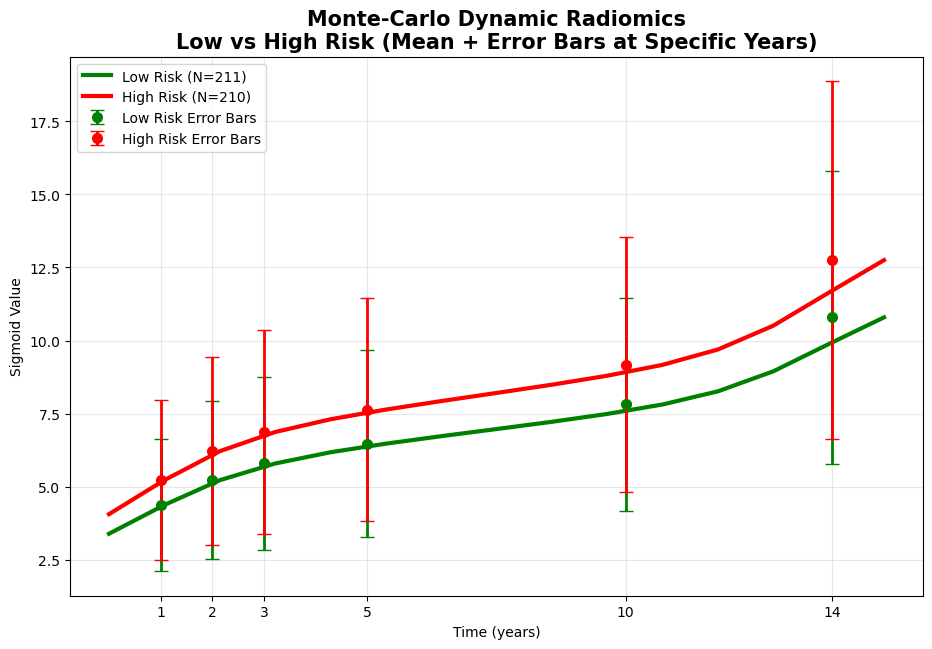


✓ Saved LOW vs HIGH MC comparison (error bars only) → data3d/results/patient_prediction/mc_low_vs_high_errorbars.png


In [4]:
# ============================================================================
# 5. VẼ: Mean curve liên tục + Error bars tại các mốc thời gian (1,2,3,...)
# ============================================================================

plt.figure(figsize=(11, 7))

# ---- Chọn các mốc thời gian để vẽ error bars ----
time_points = np.array([1, 2, 3, 5, 10, 14])   # tùy chỉnh thêm/giảm
tp_idx = time_points.astype(int)               # chuyển sang index integer


# ---- LOW RISK ----
plt.plot(t, mean_low, color="green", lw=3, label=f"Low Risk (N={len(idx_low)})")

plt.errorbar(
    time_points,
    mean_low[tp_idx],
    yerr=std_low[tp_idx],
    fmt='o',
    color="green",
    ecolor="green",
    elinewidth=2,
    capsize=5,
    markersize=7,
    label="Low Risk Error Bars"
)


# ---- HIGH RISK ----
plt.plot(t, mean_high, color="red", lw=3, label=f"High Risk (N={len(idx_high)})")

plt.errorbar(
    time_points,
    mean_high[tp_idx],
    yerr=std_high[tp_idx],
    fmt='o',
    color="red",
    ecolor="red",
    elinewidth=2,
    capsize=5,
    markersize=7,
    label="High Risk Error Bars"
)

plt.title("Monte-Carlo Dynamic Radiomics\nLow vs High Risk (Mean + Error Bars at Specific Years)",
          fontsize=15, fontweight='bold')
plt.xlabel("Time (years)")
plt.ylabel("Sigmoid Value")
plt.xticks(time_points)   # chỉ hiển thị ticks tại các mốc chọn
plt.grid(alpha=0.3)
plt.legend()

out_fig = os.path.join(OUTPUT_DIR, "mc_low_vs_high_errorbars.png")
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n✓ Saved LOW vs HIGH MC comparison (error bars only) → {out_fig}")



STEP EXTRA: DRAW 4 PATIENTS (2 LOW + 2 HIGH) IN ONE FIGURE

Selected Low-risk patients: ['LUNG1-321', 'LUNG1-010']
Selected High-risk patients: ['LUNG1-138', 'LUNG1-022']

✓ Saved one-figure comparison → data3d/results/patient_prediction/mc_four_patients_one_figure.png


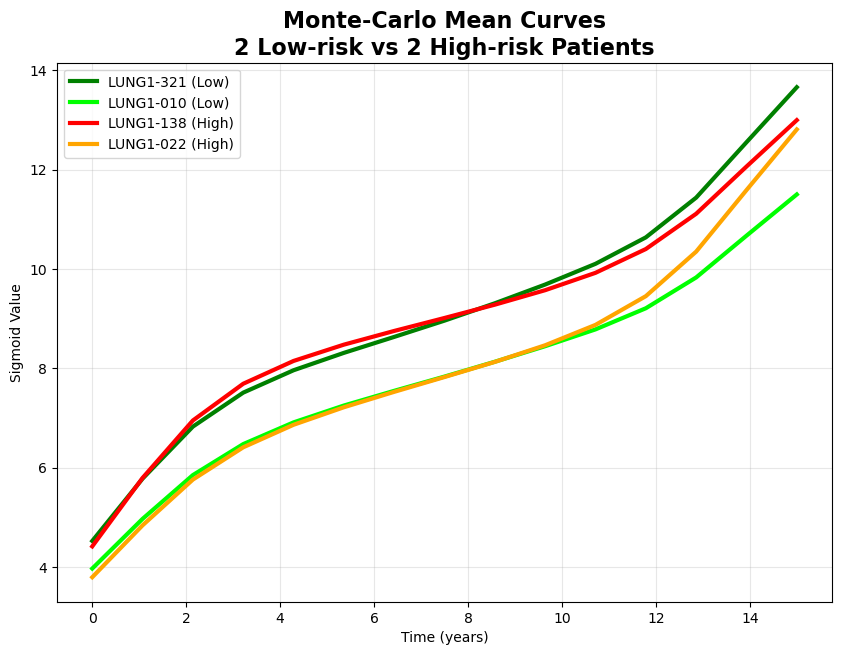

In [6]:
# ============================================================================
# STEP EXTRA: DRAW 4 PATIENTS (2 LOW, 2 HIGH) IN ONE FIGURE
# ============================================================================

print("\n" + "="*80)
print("STEP EXTRA: DRAW 4 PATIENTS (2 LOW + 2 HIGH) IN ONE FIGURE")
print("="*80)

# 1) Lấy ngẫu nhiên 2 bệnh nhân trong mỗi nhóm
low_samples = np.random.choice(idx_low, 2, replace=False)
high_samples = np.random.choice(idx_high, 2, replace=False)

print("\nSelected Low-risk patients:", [patient_ids[i] for i in low_samples])
print("Selected High-risk patients:", [patient_ids[i] for i in high_samples])

# 2) Hàm tính MC mean curve cho 1 bệnh nhân
def compute_mc_mean(idx):
    pca_vec = radiomics_pca[idx]
    curves = mc_curve(pca_vec, n_runs=N_MC_RUNS, T=T_MAX)
    mean_curve = curves.mean(axis=0)
    return mean_curve

# 3) Tính mean curves
mean_curves = {}
for idx in low_samples:
    mean_curves[patient_ids[idx]] = ("Low", compute_mc_mean(idx))

for idx in high_samples:
    mean_curves[patient_ids[idx]] = ("High", compute_mc_mean(idx))

# 4) Vẽ tất cả 4 đường trong 1 hình
plt.figure(figsize=(10, 7))
t = np.linspace(0, T_MAX, T_MAX)

color_map = {
    "Low": ["green", "lime"],
    "High": ["red", "orange"]
}

# để phân biệt 2 bệnh nhân trong cùng nhóm
low_color_i = 0
high_color_i = 0

for pid, (risk, mean_curve) in mean_curves.items():

    if risk == "Low":
        color = color_map["Low"][low_color_i % 2]
        low_color_i += 1
    else:
        color = color_map["High"][high_color_i % 2]
        high_color_i += 1

    plt.plot(t, mean_curve, lw=3, color=color, label=f"{pid} ({risk})")

plt.title("Monte-Carlo Mean Curves\n2 Low-risk vs 2 High-risk Patients",
          fontsize=16, fontweight="bold")
plt.xlabel("Time (years)")
plt.ylabel("Sigmoid Value")
plt.grid(alpha=0.3)
plt.legend(fontsize=10)

out_fig = os.path.join(OUTPUT_DIR, "mc_four_patients_one_figure.png")
plt.savefig(out_fig, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved one-figure comparison → {out_fig}")
plt.show()


In [7]:
# ==========================================================
# EXTRACT VOLUME-RELATED RADIOMICS FEATURES FOR 4 PATIENTS
# ==========================================================

# 1) Các feature liên quan trực tiếp thể tích / hình dạng
volume_features = [
    "original_shape_VoxelVolume",
    "original_shape_MeshVolume",
    "original_shape_SurfaceArea",
    "original_shape_SurfaceVolumeRatio",
    "original_shape_Compactness1",
    "original_shape_Compactness2",
    "original_shape_Sphericity",
    "original_shape_Flatness",
    "original_firstorder_TotalEnergy",
]

# 2) Mapping index theo tên
feature_to_idx = {name: i for i, name in enumerate(feature_names)}

# Check feature nào không tồn tại (tuỳ từng version Pyradiomics)
existing_volume_features = [f for f in volume_features if f in feature_to_idx]

print("✔ Volume-related features found:")
for f in existing_volume_features:
    print("    -", f)

# 3) Bệnh nhân cần phân tích
target_ids = ["LUNG1-321", "LUNG1-010", "LUNG1-138", "LUNG1-022"]

# Index của các bệnh nhân
id_to_idx = {pid: i for i, pid in enumerate(patient_ids)}
patient_indices = [id_to_idx[pid] for pid in target_ids]

# 4) Tạo bảng kết quả
import pandas as pd

rows = []
for pid in target_ids:
    idx = id_to_idx[pid]
    vec = radiomics_features[idx]

    row = {"patient_id": pid}
    for feat in existing_volume_features:
        col = feature_to_idx[feat]
        row[feat] = vec[col]

    rows.append(row)

df_volume_compare = pd.DataFrame(rows)
print("\n================ VOLUME-RELATED FEATURE TABLE ================")
print(df_volume_compare)



✔ Volume-related features found:
    - original_shape_VoxelVolume
    - original_shape_MeshVolume
    - original_shape_SurfaceArea
    - original_shape_SurfaceVolumeRatio
    - original_shape_Sphericity
    - original_shape_Flatness
    - original_firstorder_TotalEnergy

================ VOLUME-RELATED FEATURE TABLE ================
  patient_id  original_shape_VoxelVolume  original_shape_MeshVolume  \
0  LUNG1-321                   -0.722495                  -0.722070   
1  LUNG1-010                   -0.600582                  -0.600446   
2  LUNG1-138                   -0.738144                  -0.737353   
3  LUNG1-022                    0.402671                   0.402852   

   original_shape_SurfaceArea  original_shape_SurfaceVolumeRatio  \
0                   -0.924652                           0.722635   
1                   -0.612662                           0.403903   
2                   -0.972576                           0.695818   
3                    0.299870        


╔═══════════════════════════════════════════════════════════════════════════════╗
║         SURVIVAL CURVES FROM BEST MODEL (50 PCA + 20 DYNAMIC)                ║
║              Kaplan-Meier Stratification: LOW vs HIGH RISK                   ║
╚═══════════════════════════════════════════════════════════════════════════════╝

STEP 1: LOADING DATA

📂 Radiomics: data3d/outputs/features_normalized_standard.npy
   Shape: (421, 443)
📂 Clinical: nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv

STEP 2: PATIENT ID MATCHING

🔍 Matching patients...
✓ Matched 421 patients
✅ DATA SUMMARY:
   Patients: 421
   Events: 373
   Median survival: 1.50 years

STEP 3: APPLY PCA - 443 → 50 COMPONENTS

⚙️  Applying PCA with 200 components...
✓ PCA: (421, 443) → (421, 200)
   Variance explained: 99.98%

STEP 4: GENERATE DYNAMIC FEATURES FROM PCA
✓ Generated: (421, 20)

STEP 5: TRAIN BEST MODEL (50 PCA + 20 DYNAMIC)

⚙️  Training Cox model...
✓ C-Index: 0.7534
  Features: 220
  Patients: 421

STEP 6

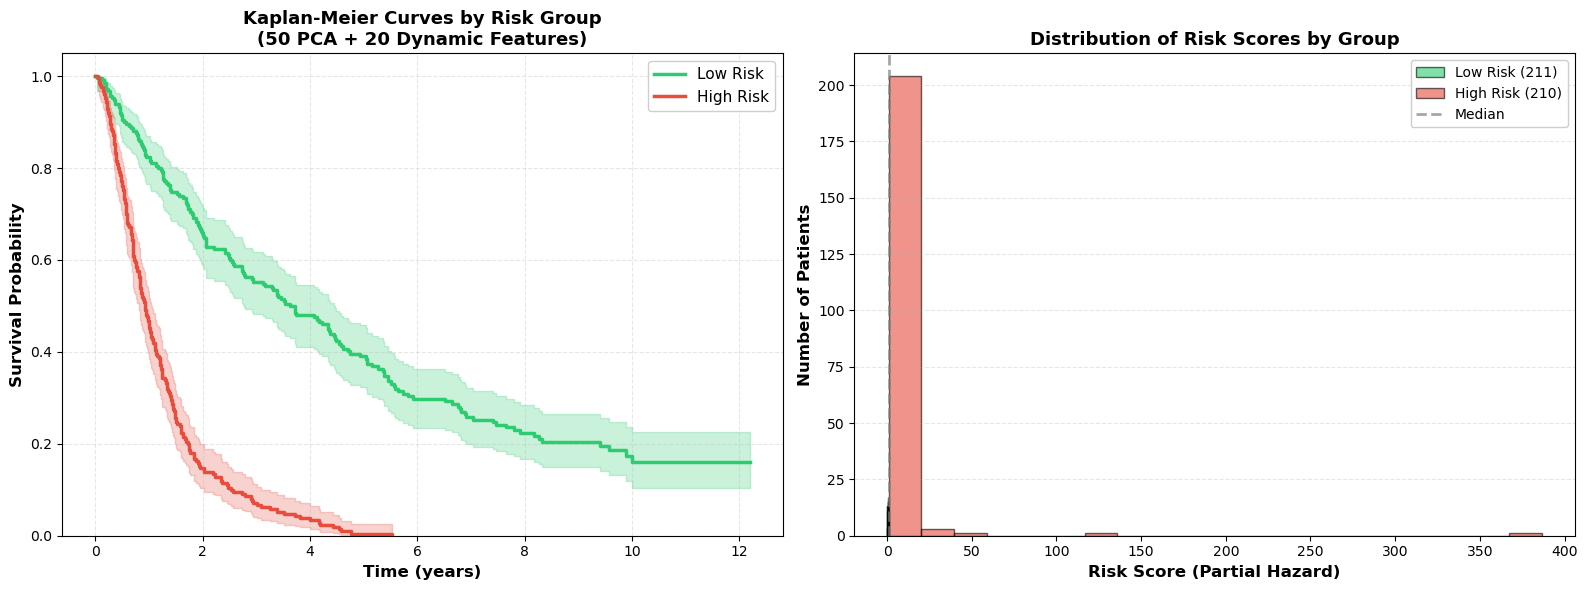


SURVIVAL STATISTICS BY RISK GROUP (LOW vs HIGH)

Risk Group  N Patients  N Events Event Rate Median Surv (yrs) Surv @ 1yr Surv @ 3yr Surv @ 5yr
       Low         211       163      77.3%              3.72     82.45%     55.28%     39.09%
      High         210       210     100.0%              0.92     46.67%      7.14%      0.48%

✓ Summary saved: data3d/results/survival_curves/survival_summary_2groups.csv

✓ Results saved: data3d/results/survival_curves/survival_analysis_results_2groups.json
✓ Data saved: data3d/results/survival_curves/survival_data_2groups.csv

✅ SURVIVAL ANALYSIS COMPLETE (LOW vs HIGH RISK)!



In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Survival Curves từ Mô Hình Tốt Nhất (2 Groups: Low & High Risk)
================================================================

Visualize Kaplan-Meier survival curves using risk scores từ Model 4:
- 50 PCA components + 20 Dynamic features
- Stratify bệnh nhân thành HIGH/LOW risk groups (binary classification)
- Log-rank test để so sánh hai nhóm

Author: Paul
Date: 2025-11-22
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║         SURVIVAL CURVES FROM BEST MODEL (50 PCA + 20 DYNAMIC)                ║
║              Kaplan-Meier Stratification: LOW vs HIGH RISK                   ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

# ============================================================================
# CONFIGURATION
# ============================================================================

RANDOM_SEED = 42
N_MC_RUNS = 500
T_MAX = 15
N_PCA_COMPONENTS = 200
OUTPUT_DIR = 'data3d/results/survival_curves'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def days_to_years(days: float) -> float:
    """Chuyển đổi ngày → năm (ngày sang năm)."""
    if pd.isna(days):
        return np.nan
    return days / 365.25


def sigmoid(t: np.ndarray, L: float, k: float, t0: float) -> np.ndarray:
    """Sigmoid function."""
    return L / (1 + np.exp(-k * (t - t0)))


def monte_carlo_from_pca(pca_vector: np.ndarray,
                         n_runs: int = 500,
                         T: int = 15,
                         seed: int = None) -> dict:
    """Generate 20 dynamic features from PCA vector."""
    if seed is not None:
        np.random.seed(seed)

    x = pca_vector  # 50 dimensions
    t = np.linspace(0, T, T)
    curves = []

    for _ in range(n_runs):
        w_L = np.random.randn(len(x))
        w_k = np.random.randn(len(x))
        w_t0 = np.random.randn(len(x))

        L = np.dot(w_L, x)
        L = abs(L) + 1e-3

        k_raw = np.dot(w_k, x)
        k = 0.1 + 0.9 * (1 / (1 + np.exp(-k_raw)))

        t0_raw = np.dot(w_t0, x)
        t0 = 0.5 + 13.5 * (1 / (1 + np.exp(-t0_raw)))

        S = sigmoid(t, L, k, t0)
        curves.append(S)

    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)
    gradient = np.gradient(mean_curve)

    auc = np.trapz(mean_curve, t)
    slope = np.max(gradient)

    half_max = 0.5 * mean_curve.max()
    time_half_idx = np.argmax(mean_curve >= half_max)
    time_half = t[time_half_idx] if time_half_idx > 0 else 0

    peak_idx = np.argmax(gradient)
    peak = mean_curve[peak_idx]

    uncertainty = std_curve.mean()
    curve_min = mean_curve.min()
    curve_max = mean_curve.max()
    curve_range = curve_max - curve_min
    curve_mean = mean_curve.mean()
    curve_median = np.median(mean_curve)
    curve_std = mean_curve.std()

    mean_grad = gradient.mean()
    max_grad = gradient.max()
    min_grad = gradient.min()
    std_grad = gradient.std()

    mid_idx = T // 3
    late_idx = 2 * T // 3

    auc_early = np.trapz(mean_curve[:mid_idx], t[:mid_idx])
    auc_mid = np.trapz(mean_curve[mid_idx:late_idx], t[mid_idx:late_idx])
    auc_late = np.trapz(mean_curve[late_idx:], t[late_idx:])
    uncertainty_variance = std_curve.var()

    curve_centered = mean_curve - curve_mean
    if curve_std > 1e-6:
        skewness = (curve_centered ** 3).mean() / (curve_std ** 3)
    else:
        skewness = 0.0

    return {
        "auc": auc, "slope": slope, "time_half": time_half, "peak": peak,
        "uncertainty": uncertainty, "curve_min": curve_min, "curve_max": curve_max,
        "curve_range": curve_range, "curve_mean": curve_mean,
        "curve_median": curve_median, "curve_std": curve_std,
        "mean_grad": mean_grad, "max_grad": max_grad, "min_grad": min_grad,
        "std_grad": std_grad, "auc_early": auc_early, "auc_mid": auc_mid,
        "auc_late": auc_late, "uncertainty_variance": uncertainty_variance,
        "skewness": skewness,
    }


def generate_dynamic_from_pca(pca_features: np.ndarray,
                              n_runs: int = 500,
                              T: int = 15) -> pd.DataFrame:
    """Generate 20 dynamic features for all patients from PCA."""
    n_patients = pca_features.shape[0]
    dynamic_features = []

    for i in range(n_patients):
        pca_vector = pca_features[i]
        result = monte_carlo_from_pca(pca_vector, n_runs=n_runs, T=T, seed=42 + i)
        dynamic_features.append([
            result["auc"], result["slope"], result["time_half"], result["peak"],
            result["uncertainty"], result["curve_min"], result["curve_max"],
            result["curve_range"], result["curve_mean"], result["curve_median"],
            result["curve_std"], result["mean_grad"], result["max_grad"],
            result["min_grad"], result["std_grad"], result["auc_early"],
            result["auc_mid"], result["auc_late"], result["uncertainty_variance"],
            result["skewness"],
        ])

    df = pd.DataFrame(dynamic_features, columns=[
        "dynamic_auc", "dynamic_slope", "dynamic_time_half", "dynamic_peak",
        "dynamic_uncertainty", "dynamic_min", "dynamic_max", "dynamic_range",
        "dynamic_mean", "dynamic_median", "dynamic_std", "dynamic_mean_grad",
        "dynamic_max_grad", "dynamic_min_grad", "dynamic_std_grad",
        "dynamic_auc_early", "dynamic_auc_mid", "dynamic_auc_late",
        "dynamic_uncertainty_var", "dynamic_skewness"
    ])
    return df


# ============================================================================
# STEP 1: LOAD DATA (giống như pipeline trên)
# ============================================================================

print("="*80)
print("STEP 1: LOADING DATA")
print("="*80)

features_path = 'data3d/outputs/features_normalized_standard.npy'
if not os.path.exists(features_path):
    features_path = 'data3d/outputs/radiomic_features_440.npy'

print(f"\n📂 Radiomics: {features_path}")
radiomics_features_all = np.load(features_path)
print(f"   Shape: {radiomics_features_all.shape}")

names_path = 'data3d/outputs/feature_names_normalized_standard.json'
with open(names_path, 'r') as f:
    feature_names = json.load(f)

ids_path = 'data3d/outputs/patient_ids.json'
with open(ids_path, 'r') as f:
    patient_ids_all = json.load(f)

clinical_paths = [
    "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
    "NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
]

clinical_data = None
for path in clinical_paths:
    if os.path.exists(path):
        clinical_data = pd.read_csv(path)
        print(f"📂 Clinical: {path}")
        break

if clinical_data is None:
    raise FileNotFoundError("Clinical data not found!")

# ============================================================================
# STEP 2: PATIENT ID MATCHING
# ============================================================================

print("\n" + "="*80)
print("STEP 2: PATIENT ID MATCHING")
print("="*80)

patient_id_col = None
for col in clinical_data.columns:
    if 'patient' in col.lower() and 'id' in col.lower():
        patient_id_col = col
        break

if patient_id_col is None:
    clinical_data['PatientID'] = clinical_data.index.astype(str)
    patient_id_col = 'PatientID'

clinical_data['PatientID_str'] = clinical_data[patient_id_col].astype(str)
patient_ids_radiomics = [str(pid) for pid in patient_ids_all]

time_col = [c for c in clinical_data.columns if 'survival.time' in c.lower()][0]
event_col = [c for c in clinical_data.columns if 'event' in c.lower() or 'deadstatus' in c.lower()][0]

print("\n🔍 Matching patients...")
matched_data = []

for i, pid in enumerate(patient_ids_radiomics):
    clinical_row = clinical_data[clinical_data['PatientID_str'] == pid]

    if len(clinical_row) == 0:
        if i < len(clinical_data):
            clinical_row = clinical_data.iloc[[i]]
        else:
            continue

    if len(clinical_row) == 0:
        continue

    time_days = clinical_row[time_col].values[0]
    event = clinical_row[event_col].values[0]

    if pd.isna(time_days) or pd.isna(event):
        continue

    time_years = days_to_years(time_days)
    radiomics_vector = radiomics_features_all[i]

    matched_data.append({
        'patient_id': pid,
        'time_years': time_years,
        'event': event,
        'radiomics_vector': radiomics_vector
    })

print(f"✓ Matched {len(matched_data)} patients")

radiomics_features = np.array([d['radiomics_vector'] for d in matched_data])
survival_df = pd.DataFrame({
    'time': [d['time_years'] for d in matched_data],
    'event': [d['event'] for d in matched_data],
    'patient_id': [d['patient_id'] for d in matched_data]
})

print(f"✅ DATA SUMMARY:")
print(f"   Patients: {len(matched_data)}")
print(f"   Events: {int(survival_df['event'].sum())}")
print(f"   Median survival: {survival_df['time'].median():.2f} years")

# ============================================================================
# STEP 3: APPLY PCA
# ============================================================================

print("\n" + "="*80)
print("STEP 3: APPLY PCA - 443 → 50 COMPONENTS")
print("="*80)

scaler_radiomics = StandardScaler()
radiomics_scaled = scaler_radiomics.fit_transform(radiomics_features)

print(f"\n⚙️  Applying PCA with {N_PCA_COMPONENTS} components...")
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
radiomics_pca = pca.fit_transform(radiomics_scaled)

explained_var = pca.explained_variance_ratio_.sum()
print(f"✓ PCA: {radiomics_scaled.shape} → {radiomics_pca.shape}")
print(f"   Variance explained: {explained_var:.2%}")

pca_df = pd.DataFrame(
    radiomics_pca,
    columns=[f"PCA_comp_{i+1}" for i in range(N_PCA_COMPONENTS)]
)

# ============================================================================
# STEP 4: GENERATE DYNAMIC FEATURES FROM PCA
# ============================================================================

print("\n" + "="*80)
print("STEP 4: GENERATE DYNAMIC FEATURES FROM PCA")
print("="*80)

dynamic_from_pca_df = generate_dynamic_from_pca(radiomics_pca, n_runs=N_MC_RUNS, T=T_MAX)

scaler_dynamic = StandardScaler()
dynamic_pca_scaled = scaler_dynamic.fit_transform(dynamic_from_pca_df)
dynamic_pca_scaled_df = pd.DataFrame(dynamic_pca_scaled, columns=dynamic_from_pca_df.columns)

print(f"✓ Generated: {dynamic_pca_scaled_df.shape}")

# ============================================================================
# STEP 5: TRAIN MODEL 4 (50 PCA + 20 DYNAMIC) - BEST MODEL
# ============================================================================

print("\n" + "="*80)
print("STEP 5: TRAIN BEST MODEL (50 PCA + 20 DYNAMIC)")
print("="*80)

# Concat features + survival data
cox_data_with_id = pd.concat([
    pca_df.reset_index(drop=True),
    dynamic_pca_scaled_df.reset_index(drop=True),
    survival_df[['time', 'event', 'patient_id']].reset_index(drop=True)
], axis=1).dropna()

# Reset index after dropna
cox_data_with_id = cox_data_with_id.reset_index(drop=True)

# Extract patient_ids and then drop from cox_data for fitting
patient_ids_cox = cox_data_with_id['patient_id'].values
cox_data = cox_data_with_id.drop('patient_id', axis=1)

print(f"\n⚙️  Training Cox model...")
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_data, duration_col='time', event_col='event', show_progress=False)

c_index = cph.concordance_index_
n_features = cox_data.shape[1] - 2  # minus 'time' and 'event'
print(f"✓ C-Index: {c_index:.4f}")
print(f"  Features: {n_features}")
print(f"  Patients: {cox_data.shape[0]}")

# ============================================================================
# STEP 6: GENERATE RISK SCORES & STRATIFY PATIENTS (2 GROUPS: LOW & HIGH)
# ============================================================================

print("\n" + "="*80)
print("STEP 6: GENERATE RISK SCORES & STRATIFY PATIENTS (LOW vs HIGH)")
print("="*80)

# Lấy features cho Cox model (drop time/event)
cox_features = cox_data.drop(['time', 'event'], axis=1)

# Tính risk scores (partial hazard)
risk_scores = cph.predict_partial_hazard(cox_features)

print(f"\n📊 Risk Score Statistics:")
print(f"   Min: {risk_scores.min():.4f}")
print(f"   Median: {risk_scores.median():.4f}")
print(f"   Max: {risk_scores.max():.4f}")
print(f"   Mean: {risk_scores.mean():.4f}")
print(f"   Std: {risk_scores.std():.4f}")

# Stratify vào 2 nhóm: Low, High risk (chia theo median)
median_risk = risk_scores.median()

risk_groups = pd.Series(
    ['Low' if x <= median_risk else 'High' for x in risk_scores],
    index=risk_scores.index
)

# Add to survival data
survival_stratified = pd.DataFrame({
    'time': cox_data['time'].values,
    'event': cox_data['event'].values,
    'risk_score': risk_scores.values,
    'risk_group': risk_groups.values,
    'patient_id': patient_ids_cox
})

print(f"\n📊 Risk Group Distribution (Binary Classification):")
for group in ['Low', 'High']:
    n_group = (risk_groups == group).sum()
    n_events = survival_stratified[survival_stratified['risk_group'] == group]['event'].sum()
    median_surv = survival_stratified[survival_stratified['risk_group'] == group]['time'].median()
    print(f"   {group:6s}: {n_group:3d} patients | {int(n_events):3d} events | Median: {median_surv:.2f} years")

print(f"\n   Median threshold: {median_risk:.4f}")

# ============================================================================
# STEP 7: CREATE KAPLAN-MEIER SURVIVAL CURVES (LOW vs HIGH)
# ============================================================================

print("\n" + "="*80)
print("STEP 7: KAPLAN-MEIER SURVIVAL CURVES (LOW vs HIGH)")
print("="*80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

kmf = KaplanMeierFitter()
colors = {'Low': '#2ecc71', 'High': '#e74c3c'}
risk_order = ['Low', 'High']

# ─────────────────────────────────────────────────────────────────────────
# Plot 1: Survival Curves
# ─────────────────────────────────────────────────────────────────────────

print("\n📈 Plotting Kaplan-Meier curves...")

for group in risk_order:
    mask = survival_stratified['risk_group'] == group
    kmf.fit(
        survival_stratified[mask]['time'],
        survival_stratified[mask]['event'],
        label=f'{group} Risk'
    )
    kmf.plot_survival_function(ax=ax1, ci_show=True, color=colors[group], linewidth=2.5)

ax1.set_xlabel('Time (years)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Survival Probability', fontsize=12, fontweight='bold')
ax1.set_title('Kaplan-Meier Curves by Risk Group\n(50 PCA + 20 Dynamic Features)',
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.set_ylim([0, 1.05])

# ─────────────────────────────────────────────────────────────────────────
# Log-Rank Tests (Low vs High only)
# ─────────────────────────────────────────────────────────────────────────

print("\n🔬 Log-Rank Test (Low vs High):")

low_mask = survival_stratified['risk_group'] == 'Low'
high_mask = survival_stratified['risk_group'] == 'High'

results = logrank_test(
    survival_stratified[low_mask]['time'],
    survival_stratified[high_mask]['time'],
    survival_stratified[low_mask]['event'],
    survival_stratified[high_mask]['event']
)

print(f"\n   Test statistic: {results.test_statistic:.4f}")
print(f"   P-value: {results.p_value:.6f}")
if results.p_value < 0.05:
    print(f"   ✓ SIGNIFICANT (p < 0.05)")
else:
    print(f"   ✗ Not significant")

# ─────────────────────────────────────────────────────────────────────────
# Plot 2: Risk Score Distribution
# ─────────────────────────────────────────────────────────────────────────

for group in risk_order:
    mask = survival_stratified['risk_group'] == group
    data = survival_stratified[mask]['risk_score']
    ax2.hist(data, bins=20, alpha=0.6, label=f'{group} Risk ({len(data)})',
             color=colors[group], edgecolor='black', linewidth=1)

ax2.axvline(median_risk, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Median')
ax2.set_xlabel('Risk Score (Partial Hazard)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Risk Scores by Group', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=10, framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kaplan_meier_survival_curves_2groups.png'), dpi=300, bbox_inches='tight')
print(f"\n✓ Survival curves saved: {OUTPUT_DIR}/kaplan_meier_survival_curves_2groups.png")

plt.show()

# ============================================================================
# STEP 8: SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("SURVIVAL STATISTICS BY RISK GROUP (LOW vs HIGH)")
print("="*80)


def get_survival_at_time(kmf, time_point):
    """Get survival probability at specific time point from KM curve."""
    if len(kmf.survival_function_) == 0:
        return np.nan

    sf = kmf.survival_function_
    times = sf.index.values
    probs = sf.values.flatten()

    # Find the latest time <= time_point
    mask = times <= time_point
    if not mask.any():
        return np.nan

    idx = np.where(mask)[0][-1]
    return probs[idx]


summary_stats = []

for group in risk_order:
    mask = survival_stratified['risk_group'] == group
    group_data = survival_stratified[mask]

    kmf = KaplanMeierFitter()
    kmf.fit(group_data['time'], group_data['event'], label=group)

    # Median survival from the median_survival_time_ attribute
    try:
        median_surv = kmf.median_survival_time_
    except:
        median_surv = group_data[group_data['event'] == 1]['time'].median()

    # Survival at 1, 3, 5 years using helper function
    surv_1yr = get_survival_at_time(kmf, 1.0)
    surv_3yr = get_survival_at_time(kmf, 3.0)
    surv_5yr = get_survival_at_time(kmf, 5.0)

    summary_stats.append({
        'Risk Group': group,
        'N Patients': len(group_data),
        'N Events': int(group_data['event'].sum()),
        'Event Rate': f"{group_data['event'].sum() / len(group_data) * 100:.1f}%",
        'Median Surv (yrs)': f"{median_surv:.2f}" if pd.notna(median_surv) else "N/A",
        'Surv @ 1yr': f"{surv_1yr:.2%}" if pd.notna(surv_1yr) else "N/A",
        'Surv @ 3yr': f"{surv_3yr:.2%}" if pd.notna(surv_3yr) else "N/A",
        'Surv @ 5yr': f"{surv_5yr:.2%}" if pd.notna(surv_5yr) else "N/A",
    })

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'survival_summary_2groups.csv'), index=False)
print(f"\n✓ Summary saved: {OUTPUT_DIR}/survival_summary_2groups.csv")

# ============================================================================
# SAVE RESULTS
# ============================================================================

results_dict = {
    'model_config': {
        'model_type': 'Cox Proportional Hazards',
        'features': '50 PCA + 20 Dynamic',
        'penalizer': 0.1,
        'c_index': float(c_index),
        'variance_explained_pca': float(explained_var)
    },
    'stratification': {
        'method': 'Binary classification by median risk score',
        'median_threshold': float(median_risk),
        'groups': 2
    },
    'logrank_test': {
        'low_vs_high': {
            'test_statistic': float(results.test_statistic),
            'p_value': float(results.p_value),
            'significant': bool(results.p_value < 0.05)
        }
    },
    'risk_groups': {
        group: {
            'n_patients': int((risk_groups == group).sum()),
            'n_events': int(survival_stratified[survival_stratified['risk_group'] == group]['event'].sum())
        }
        for group in risk_order
    }
}

results_path = os.path.join(OUTPUT_DIR, 'survival_analysis_results_2groups.json')
with open(results_path, 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"\n✓ Results saved: {results_path}")

# Save stratified survival data
survival_stratified.to_csv(os.path.join(OUTPUT_DIR, 'survival_data_2groups.csv'), index=False)
print(f"✓ Data saved: {OUTPUT_DIR}/survival_data_2groups.csv")

print("\n" + "="*80)
print("✅ SURVIVAL ANALYSIS COMPLETE (LOW vs HIGH RISK)!")
print("="*80 + "\n")

In [19]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Individual Patient Risk Prediction (Standalone version)
========================================================
- Train Cox model on first 80% patients
- Test / inference on remaining 20%
- PCA (200 comps) + Monte Carlo dynamic features (20)
- Cox model training on TRAIN ONLY
- Prediction + KM curve using TRAIN distribution
Author: Paul (converted & modified by ChatGPT)
Date: 2025-11-18
"""

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from typing import Dict, Tuple

import warnings
warnings.filterwarnings('ignore')

# =====================================================================================
# CONFIGURATION
# =====================================================================================

RANDOM_SEED = 42
N_MC_RUNS = 300        # giảm còn 300 cho Spaces
T_MAX = 15
N_PCA_COMPONENTS = 200
OUTPUT_DIR = 'results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)

# =====================================================================================
# UTILITY FUNCTIONS
# =====================================================================================

def days_to_years(days: float) -> float:
    return np.nan if pd.isna(days) else days / 365.25


def sigmoid(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))


def monte_carlo_from_pca(x: np.ndarray, n_runs=300, T=15, seed=None) -> Dict:
    if seed is not None:
        np.random.seed(seed)

    t = np.linspace(0, T, T)
    curves = []

    for _ in range(n_runs):
        wL = np.random.randn(len(x))
        wk = np.random.randn(len(x))
        wt = np.random.randn(len(x))

        L = abs(np.dot(wL, x)) + 1e-3
        k_raw = np.dot(wk, x)
        k = 0.1 + 0.9 * (1 / (1 + np.exp(-k_raw)))
        t0_raw = np.dot(wt, x)
        t0 = 0.5 + 13.5 * (1 / (1 + np.exp(-t0_raw)))

        curves.append(sigmoid(t, L, k, t0))

    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)
    grad = np.gradient(mean_curve)

    auc = np.trapz(mean_curve, t)
    halfmax = 0.5 * mean_curve.max()
    th_idx = np.argmax(mean_curve >= halfmax)
    time_half = t[th_idx] if th_idx > 0 else 0

    mid = T // 3
    late = 2 * T // 3

    curve_mean = mean_curve.mean()
    curve_std = mean_curve.std()

    return {
        "auc": auc,
        "slope": np.max(grad),
        "time_half": time_half,
        "peak": mean_curve[np.argmax(grad)],
        "uncertainty": std_curve.mean(),
        "curve_min": mean_curve.min(),
        "curve_max": mean_curve.max(),
        "curve_range": mean_curve.max() - mean_curve.min(),
        "curve_mean": curve_mean,
        "curve_median": np.median(mean_curve),
        "curve_std": curve_std,
        "mean_grad": grad.mean(),
        "max_grad": grad.max(),
        "min_grad": grad.min(),
        "std_grad": grad.std(),
        "auc_early": np.trapz(mean_curve[:mid], t[:mid]),
        "auc_mid": np.trapz(mean_curve[mid:late], t[mid:late]),
        "auc_late": np.trapz(mean_curve[late:], t[late:]),
        "uncertainty_variance": std_curve.var(),
        "skewness": 0 if curve_std < 1e-6 else ((mean_curve - curve_mean)**3).mean() / (curve_std**3)
    }


def generate_dynamic_from_pca(pca_features):
    rows = []
    for i in range(len(pca_features)):
        r = monte_carlo_from_pca(pca_features[i], n_runs=N_MC_RUNS, T=T_MAX, seed=42+i)
        rows.append(list(r.values()))
    return pd.DataFrame(rows, columns=[
        "dynamic_auc", "dynamic_slope", "dynamic_time_half", "dynamic_peak",
        "dynamic_uncertainty", "dynamic_min", "dynamic_max", "dynamic_range",
        "dynamic_mean", "dynamic_median", "dynamic_std", "dynamic_mean_grad",
        "dynamic_max_grad", "dynamic_min_grad", "dynamic_std_grad",
        "dynamic_auc_early", "dynamic_auc_mid", "dynamic_auc_late",
        "dynamic_uncertainty_var", "dynamic_skewness"
    ])

# =====================================================================================
# GLOBAL VARIABLES (initialized by load_and_prepare_data)
# =====================================================================================

patient_ids = []
patient_ids_train = []
patient_ids_test = []
times = None
events = None
times_train = None
events_train = None
times_test = None
events_test = None
cox_df_all = None
cox_df_train = None
cox_df_test = None
cph = None
scores_train = None
C_INDEX_TRAIN = None
c_index_test = None

# =====================================================================================
# STEP 1 — LOAD AND PREPARE DATA
# =====================================================================================

def load_and_prepare_data():
    """Load data, perform train/test split, fit PCA and Cox model"""
    global patient_ids, patient_ids_train, patient_ids_test
    global times, events, times_train, events_train, times_test, events_test
    global cox_df_all, cox_df_train, cox_df_test
    global cph, scores_train, C_INDEX_TRAIN, c_index_test

    print("Loading radiomics & clinical data...")

    # Try data3d/outputs/ first, then fall back to root directory
    features_path = 'data3d/outputs/features_normalized_standard.npy'
    if not os.path.exists(features_path):
        features_path = 'features_normalized_standard.npy'
    if not os.path.exists(features_path):
        features_path = 'data3d/outputs/radiomic_features_440.npy'
    if not os.path.exists(features_path):
        features_path = 'radiomic_features_440.npy'

    print(f"\n📂 Radiomics: {features_path}")
    radiomics_all = np.load(features_path)
    print(f"   Shape: {radiomics_all.shape}")

    # Load patient IDs
    ids_path = 'data3d/outputs/patient_ids.json'
    if not os.path.exists(ids_path):
        ids_path = 'patient_ids.json'

    with open(ids_path, 'r') as f:
        pat_ids_all = json.load(f)

    print(f"   Patient IDs loaded: {len(pat_ids_all)}")

    clinical_paths = [
        "nsclc/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
        "NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv",
    ]

    clinical_data = None
    for path in clinical_paths:
        if os.path.exists(path):
            clinical_data = pd.read_csv(path)
            break

    if clinical_data is None:
        raise FileNotFoundError("Clinical CSV not found. Please check path.")

    # match data
    clinical_data['pid'] = clinical_data.iloc[:, 0].astype(str)
    pat_ids_all = [str(x) for x in pat_ids_all]

    matched = []
    time_col = [c for c in clinical_data.columns if "survival" in c.lower()][0]
    event_col = [c for c in clinical_data.columns if "event" in c.lower() or "dead" in c.lower()][0]

    for i, pid in enumerate(pat_ids_all):
        row = clinical_data[clinical_data['pid'] == pid]
        if len(row) == 0:
            continue
        row = row.iloc[0]

        if pd.isna(row[time_col]) or pd.isna(row[event_col]):
            continue

        matched.append({
            "patient_id": pid,
            "time": days_to_years(row[time_col]),
            "event": row[event_col],
            "feat": radiomics_all[i]
        })

    patient_ids = [m['patient_id'] for m in matched]
    times = np.array([m['time'] for m in matched])
    events = np.array([m['event'] for m in matched])
    radiomics = np.array([m['feat'] for m in matched])

    N = len(patient_ids)
    if N < 10:
        print(f"Warning: only {N} patients matched.")

    # =====================================================================================
    # STEP 2 — SPLIT INTO TRAIN (80%) AND TEST (20%)
    # =====================================================================================

    n_train = int(0.8 * N)
    train_idx = np.arange(n_train)
    test_idx = np.arange(n_train, N)

    patient_ids_train = [patient_ids[i] for i in train_idx]
    patient_ids_test = [patient_ids[i] for i in test_idx]

    times_train = times[train_idx]
    events_train = events[train_idx]
    times_test = times[test_idx]
    events_test = events[test_idx]

    rad_train = radiomics[train_idx]
    rad_test = radiomics[test_idx]

    print(f"Total patients: {N}")
    print(f"Train: {len(train_idx)} (first 80%), Test: {len(test_idx)} (last 20%)")

    # =====================================================================================
    # STEP 3 — SCALER + PCA FIT ON TRAIN, APPLY TO ALL
    # =====================================================================================

    scaler = StandardScaler()
    rad_scaled_train = scaler.fit_transform(rad_train)
    rad_scaled_all = scaler.transform(radiomics)  # dùng cùng scaler cho ALL (train+test)

    pca = PCA(n_components=N_PCA_COMPONENTS)
    pca.fit(rad_scaled_train)
    rad_pca_all = pca.transform(rad_scaled_all)
    rad_pca_train = rad_pca_all[train_idx, :]
    rad_pca_test = rad_pca_all[test_idx, :]

    # =====================================================================================
    # STEP 4 — MONTE CARLO DYNAMIC FEATURES (FIT SCALER ON TRAIN)
    # =====================================================================================

    print("Generating dynamic features using Monte Carlo...")
    dyn_df_all = generate_dynamic_from_pca(rad_pca_all)
    dyn_df_train = dyn_df_all.iloc[train_idx]
    dyn_df_test = dyn_df_all.iloc[test_idx]

    scaler_dyn = StandardScaler()
    dyn_scaled_train = scaler_dyn.fit_transform(dyn_df_train)
    dyn_scaled_all = scaler_dyn.transform(dyn_df_all)

    dyn_scaled_df_all = pd.DataFrame(dyn_scaled_all, columns=dyn_df_all.columns)
    dyn_scaled_df_train = dyn_scaled_df_all.iloc[train_idx]
    dyn_scaled_df_test = dyn_scaled_df_all.iloc[test_idx]

    # =====================================================================================
    # STEP 5 — BUILD COX DATAFRAMES (TRAIN / TEST)
    # =====================================================================================

    pca_cols = [f"PCA_{i}" for i in range(N_PCA_COMPONENTS)]

    cox_df_all = pd.concat([
        pd.DataFrame(rad_pca_all, columns=pca_cols),
        dyn_scaled_df_all,
        pd.DataFrame({"time": times, "event": events})
    ], axis=1)

    cox_df_train = cox_df_all.iloc[train_idx].reset_index(drop=True)
    cox_df_test = cox_df_all.iloc[test_idx].reset_index(drop=True)

    # =====================================================================================
    # STEP 6 — FIT COX MODEL ON TRAIN ONLY
    # =====================================================================================

    print("Fitting Cox proportional hazards model...")
    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(cox_df_train, duration_col='time', event_col='event')
    C_INDEX_TRAIN = cph.concordance_index_

    # Đánh giá C-index trên test (optional nhưng hữu ích)
    X_test = cox_df_test.drop(columns=["time", "event"])
    risk_test = cph.predict_partial_hazard(X_test).values
    c_index_test = concordance_index(cox_df_test["time"], -risk_test, cox_df_test["event"])

    print(f"Cox model trained on TRAIN set:")
    print(f"  - C-index (train): {C_INDEX_TRAIN:.4f}")
    print(f"  - C-index (test):  {c_index_test:.4f}")

    # Precompute train risk scores for percentile & risk group
    X_train = cox_df_train.drop(columns=["time", "event"])
    scores_train = cph.predict_partial_hazard(X_train)

    print("Data loaded and model trained successfully!\n")

# =====================================================================================
# SURVIVAL TIME PREDICTION
# =====================================================================================

def predict_survival_time(patient_features: pd.DataFrame) -> float:
    """
    Predict survival time for a patient using Cox model

    Args:
        patient_features: DataFrame containing patient features (without time/event)

    Returns:
        Predicted median survival time in years
    """
    # Get survival function for this patient
    surv_func = cph.predict_survival_function(patient_features)

    # Extract the survival probabilities
    surv_probs = surv_func.iloc[:, 0]

    # Find median survival time (where survival probability = 0.5)
    # If median is not reached, use restricted mean survival time
    try:
        median_time = surv_func.quantile(0.5).iloc[0]
    except:
        # If median survival time cannot be determined (curve doesn't reach 0.5)
        # Use restricted mean survival time
        times = surv_func.index.values
        probs = surv_probs.values
        # Calculate area under curve (restricted mean)
        median_time = np.trapz(probs, times)

    return float(median_time)


# =====================================================================================
# MAIN FUNCTION — RUN FOR ANY PATIENT ID (TRAIN OR TEST)
# =====================================================================================

def predict_patient(patient_id: str, save_plot: bool = True, show_plot: bool = False) -> Dict:
    """
    Predict risk for a given patient ID

    Args:
        patient_id: Patient ID to predict
        save_plot: Whether to save the Kaplan-Meier plot
        show_plot: Whether to display the plot

    Returns:
        Dictionary containing prediction results
    """
    if patient_id not in patient_ids:
        return {"error": f"Patient {patient_id} not found."}

    # index trong toàn bộ danh sách (train + test)
    idx_all = patient_ids.index(patient_id)
    row_all = cox_df_all.iloc[idx_all]

    # feature cho bệnh nhân (PCA + dynamic), không gồm time/event
    feat = row_all.drop(["time", "event"]).to_frame().T
    risk = cph.predict_partial_hazard(feat).values[0]

    # Dự đoán survival time
    predicted_survival_time = predict_survival_time(feat)
    actual_survival_time = float(row_all['time'])

    # Tính sai số
    absolute_error = abs(predicted_survival_time - actual_survival_time)
    relative_error = (absolute_error / actual_survival_time * 100) if actual_survival_time > 0 else 0

    # percentile & risk group sử dụng PHÂN PHỐI TRAIN
    percentile = float((scores_train <= risk).mean() * 100)

    t33 = scores_train.quantile(0.33)
    t67 = scores_train.quantile(0.67)
    if risk <= t33:
        group = "Low"
    elif risk <= t67:
        group = "Medium"
    else:
        group = "High"

    # thông tin train/test
    cohort = "TRAIN" if patient_id in patient_ids_train else "TEST"

    # KM curve dựa trên TRAIN set
    if save_plot or show_plot:
        fig = plt.figure(figsize=(8, 6))
        kmf = KaplanMeierFitter()

        if group == "Low":
            mask = scores_train <= t33
        elif group == "Medium":
            mask = (scores_train <= t67) & (scores_train > t33)
        else:
            mask = scores_train > t67

        kmf.fit(cox_df_train[mask]["time"], cox_df_train[mask]["event"],
                label=f"{group} risk (TRAIN)")
        kmf.plot_survival_function(ci_show=False, linewidth=2)

        # đánh dấu vị trí bệnh nhân (time/event) trên KM curve
        plt.scatter([row_all["time"]], [1 - row_all["event"]],
                    s=150, marker='*', edgecolors="black", c='red')
        plt.title(f"Kaplan–Meier: Patient {patient_id} ({group} risk)")
        plt.xlabel("Time (years)")
        plt.ylabel("Survival probability")

        if save_plot:
            fig_path = f"{OUTPUT_DIR}/km_{patient_id}.png"
            plt.savefig(fig_path, dpi=200, bbox_inches="tight")
            print(f"Plot saved to: {fig_path}")

        if show_plot:
            plt.show()
        else:
            plt.close()

    # Return results as dictionary
    results = {
        "patient_id": patient_id,
        "cohort": cohort,
        "risk_score": float(risk),
        "percentile": float(percentile),
        "risk_group": group,
        "actual_survival_time": actual_survival_time,
        "predicted_survival_time": predicted_survival_time,
        "absolute_error": absolute_error,
        "relative_error_pct": relative_error,
        "event": int(row_all['event']),
        "c_index_train": float(C_INDEX_TRAIN),
        "c_index_test": float(c_index_test)
    }

    return results


def print_prediction_results(results: Dict):
    """Pretty print prediction results"""
    if "error" in results:
        print(f"❌ {results['error']}")
        return

    print("\n" + "="*60)
    print(f"PREDICTION RESULTS FOR PATIENT {results['patient_id']}")
    print("="*60)
    print(f"Cohort:                    {results['cohort']}")
    print(f"Risk Score:                {results['risk_score']:.4f}")
    print(f"Percentile:                {results['percentile']:.1f}% (vs TRAIN)")
    print(f"Risk Group:                {results['risk_group']}")
    print("-"*60)
    print(f"Survival Time Prediction:")
    print(f"  Actual:                  {results['actual_survival_time']:.2f} years")
    print(f"  Predicted:               {results['predicted_survival_time']:.2f} years")
    print(f"  Absolute Error:          {results['absolute_error']:.2f} years")
    print(f"  Relative Error:          {results['relative_error_pct']:.1f}%")
    print(f"  Event Occurred:          {results['event']}")
    print("-"*60)
    print(f"Model Performance:")
    print(f"  C-index (train):         {results['c_index_train']:.4f}")
    print(f"  C-index (test):          {results['c_index_test']:.4f}")
    print("="*60 + "\n")


def batch_predict(patient_ids_list: list, save_plots: bool = True) -> pd.DataFrame:
    """
    Predict risk for multiple patients

    Args:
        patient_ids_list: List of patient IDs
        save_plots: Whether to save plots for each patient

    Returns:
        DataFrame with all predictions
    """
    results_list = []
    for pid in patient_ids_list:
        result = predict_patient(pid, save_plot=save_plots, show_plot=False)
        if "error" not in result:
            results_list.append(result)
        else:
            print(f"Skipping {pid}: {result['error']}")

    return pd.DataFrame(results_list)


# =====================================================================================
# MAIN SCRIPT
# =====================================================================================

if __name__ == "__main__":
    # Load data and train model
    load_and_prepare_data()


    # Default: Run predictions for ALL test patients
    # Run batch prediction for all test patients (no plots)
    test_results = batch_predict(patient_ids_test, save_plots=False)

    # Convert years to days (rounded to integer)
    test_results['predicted_days'] = (test_results['predicted_survival_time'] * 365.25).round(0).astype(int)
    test_results['actual_days'] = (test_results['actual_survival_time'] * 365.25).round(0).astype(int)

    # Display only patient_id, predicted_days, actual_days
    print(test_results[["patient_id", "predicted_days", "actual_days"]].to_string(index=False))

Loading radiomics & clinical data...

📂 Radiomics: data3d/outputs/features_normalized_standard.npy
   Shape: (421, 443)
   Patient IDs loaded: 421
Total patients: 421
Train: 336 (first 80%), Test: 85 (last 20%)
Generating dynamic features using Monte Carlo...
Fitting Cox proportional hazards model...
Cox model trained on TRAIN set:
  - C-index (train): 0.7908
  - C-index (test):  0.5376
Data loaded and model trained successfully!

patient_id  predicted_days  actual_days
 LUNG1-338              52          118
 LUNG1-339             212          120
 LUNG1-340             138          859
 LUNG1-341             252         1157
 LUNG1-342             351          166
 LUNG1-343               0          337
 LUNG1-344              74          587
 LUNG1-345             188         3185
 LUNG1-346               0         1967
 LUNG1-347             357         1586
 LUNG1-348               0         1672
 LUNG1-349               0          183
 LUNG1-350              86          444
 LUNG